<a href="https://colab.research.google.com/github/joy9808/2026-DA1/blob/main/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

In [10]:
!pip install pydataset
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [11]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [12]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [13]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [17]:
display_series_side_by_side(iris['Petal.Length'][:5], iris.Species.value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [20]:
display_series_side_by_side(iris['Petal.Length'][:5].to_frame(), iris.Species.value_counts().to_frame())

AttributeError: 'DataFrame' object has no attribute 'name'

In [25]:
plt.rcParams['figure.figsize'] = (5, 3)

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


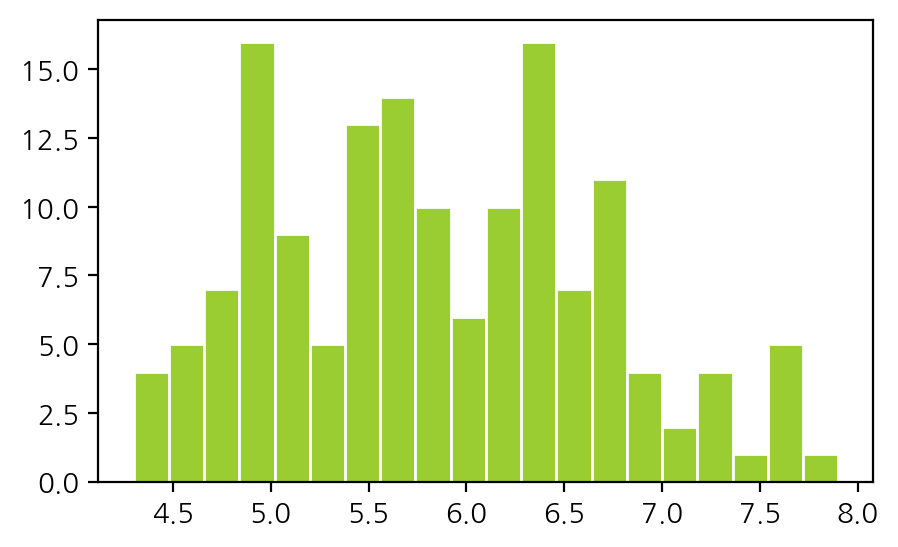

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20, color = 'yellowgreen', edgecolor = 'white')
print(n)
print(bins)
print(patches)

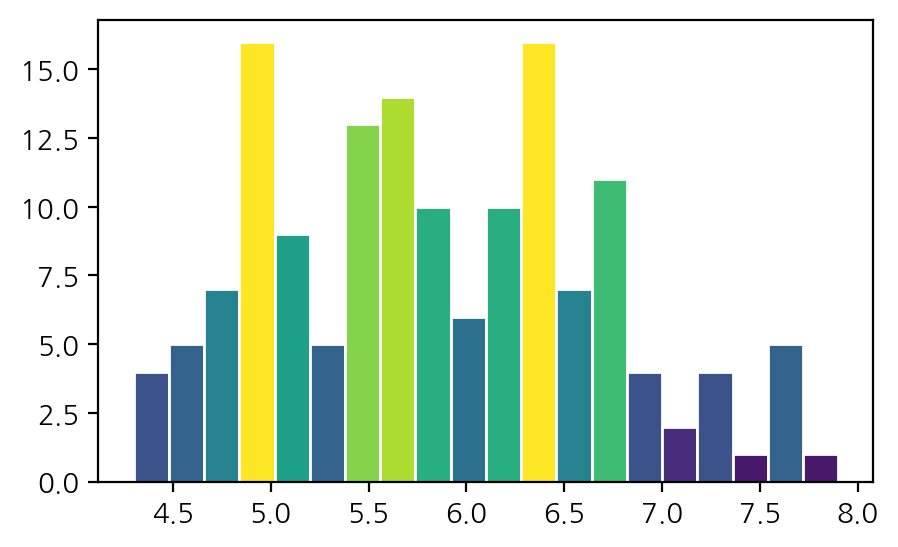

In [27]:
n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20, color='yellowgreen' ,edgecolor='white')
for i in range(len(patches)):
  patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
plt.show()

<Axes: ylabel='Density'>

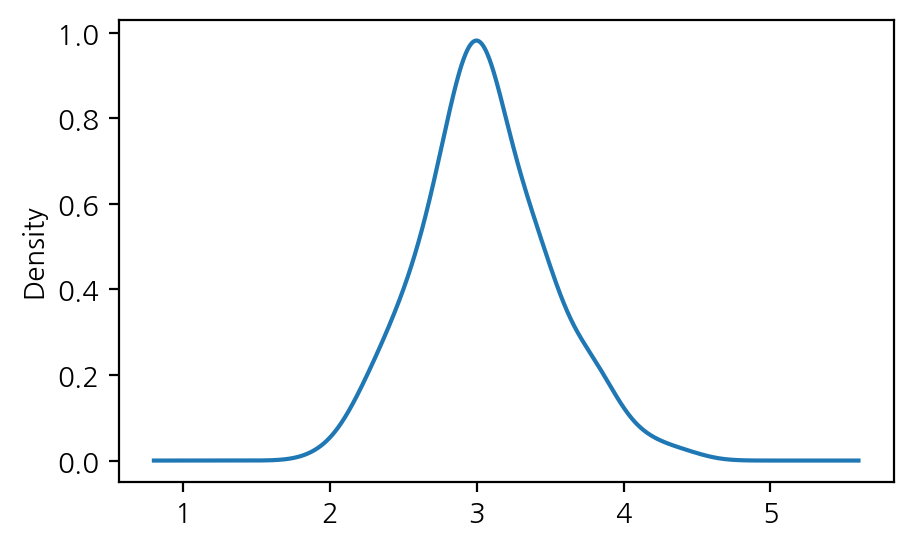

In [29]:
iris['Sepal.Width'].plot.density()

<Axes: ylabel='Density'>

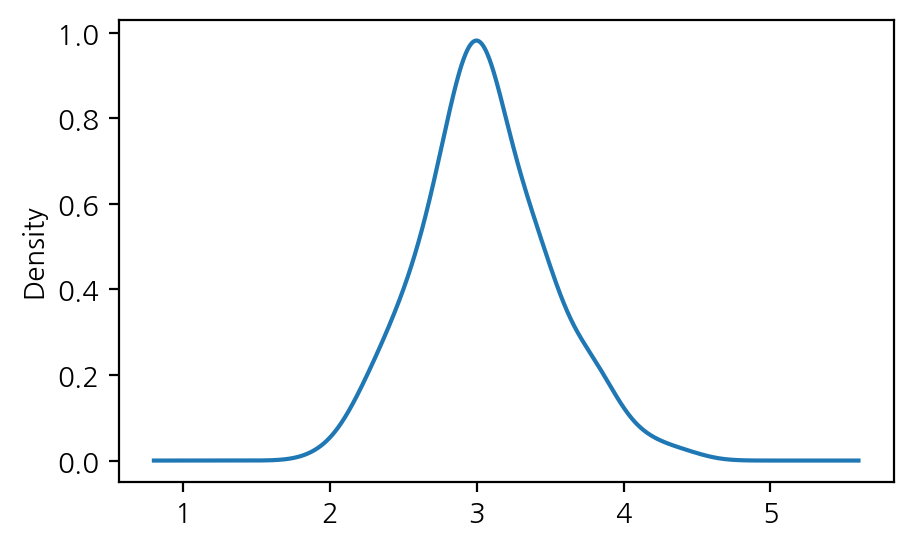

In [30]:
iris['Sepal.Width'].plot.kde()

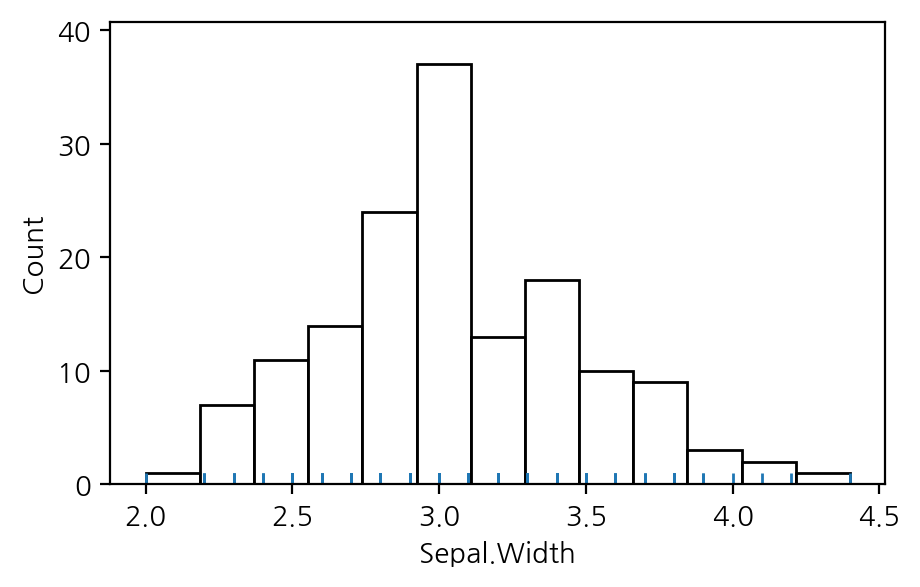

In [31]:
import seaborn as sns
sns.histplot(data=iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x = iris['Sepal.Width']);

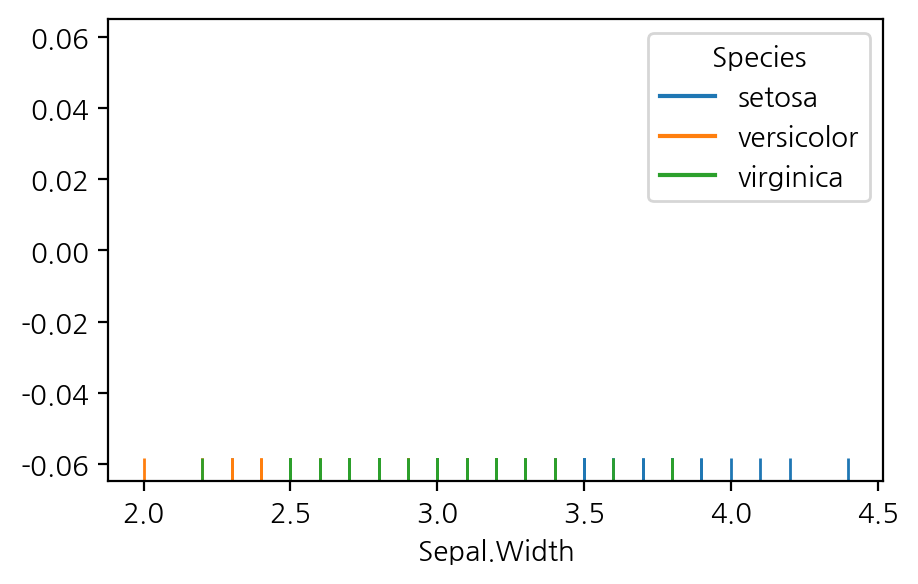

In [33]:
sns.rugplot(data = iris, x = iris['Sepal.Width'],
height=0.05, hue='Species');

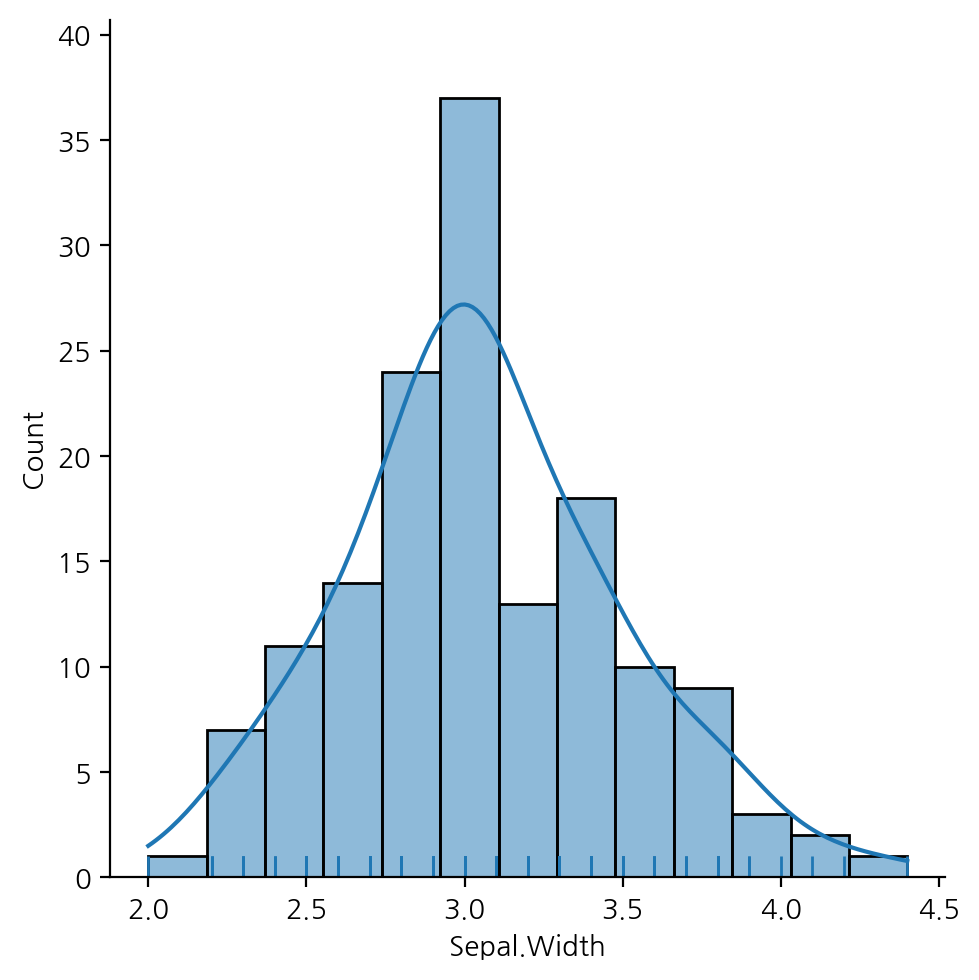

In [34]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True);

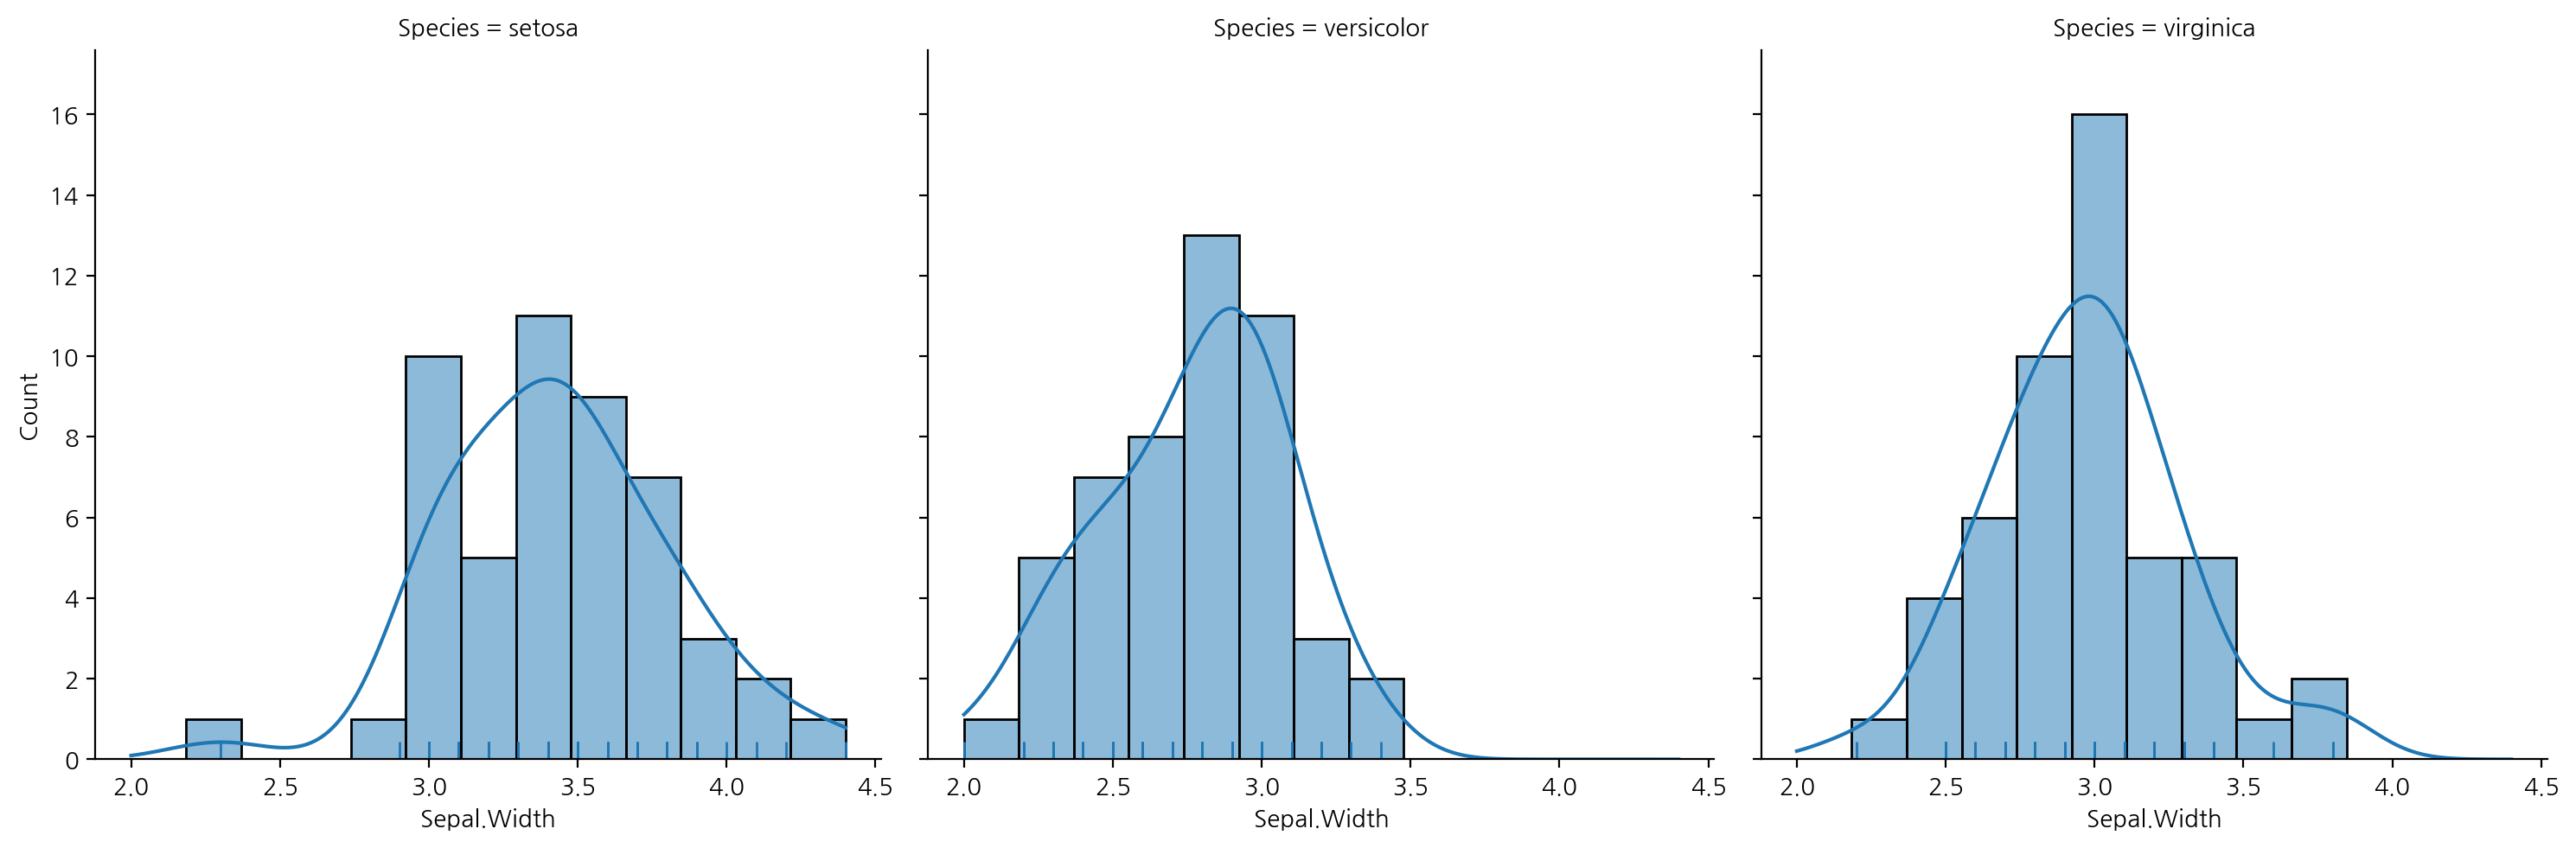

In [35]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], col="Species",
kde=True, rug=True);

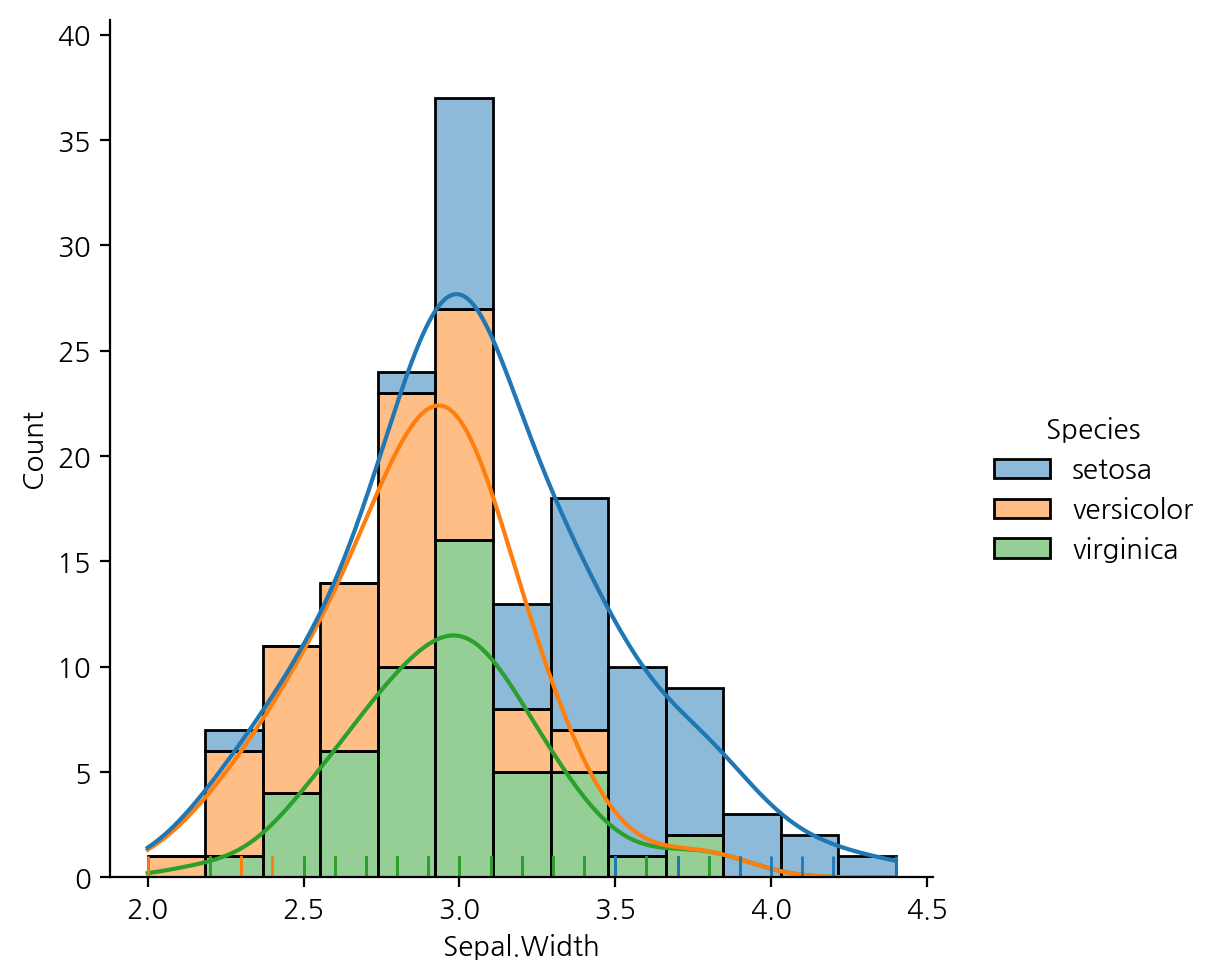

In [36]:
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True,
multiple="stack", hue="Species");

In [58]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [60]:
pd.set_option('display.precision', 2)
corr_iris = iris[iris.columns[:-1].to_list()].corr()
corr_iris

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


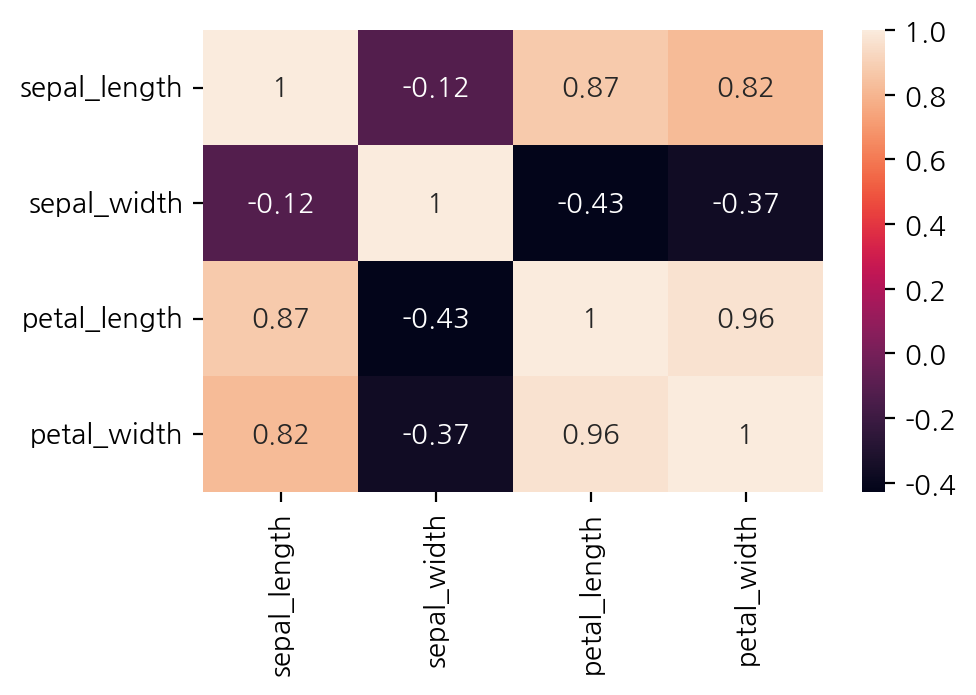

In [61]:
sns.heatmap(corr_iris, annot=True);

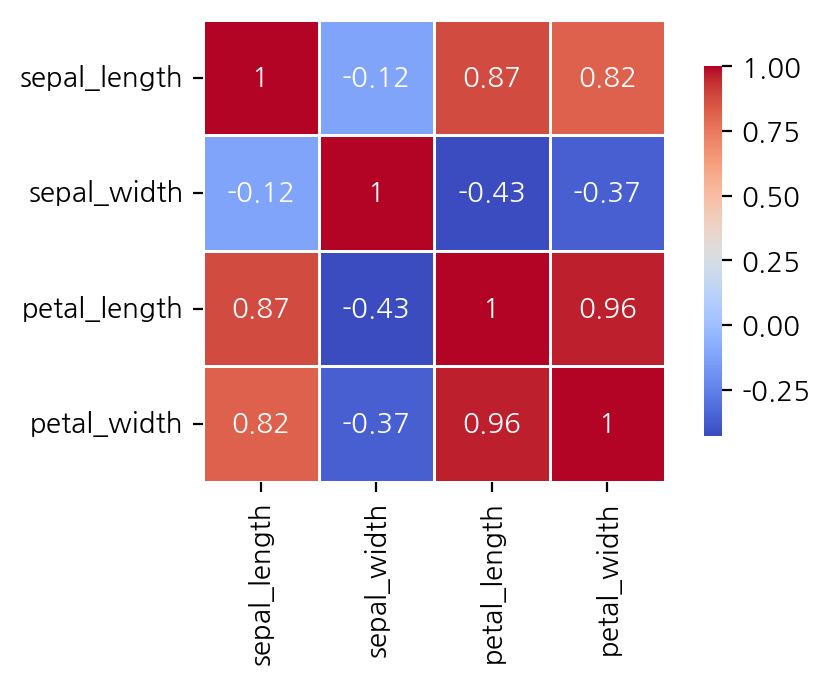

In [63]:
sns.heatmap(corr_iris, annot=True, cmap='coolwarm', square = True, linewidths = 0.5, cbar_kws = {'shrink':0.8});

In [64]:
mask = np.zeros_like(corr_iris)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [65]:
np,np.triu_indices_from(mask)

(<module 'numpy' from '/usr/local/lib/python3.12/dist-packages/numpy/__init__.py'>,
 (array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]),
  array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3])))

In [68]:
mask[np.triu_indices_from(mask)] = 1
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [69]:
mask_new = mask[1:, :-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

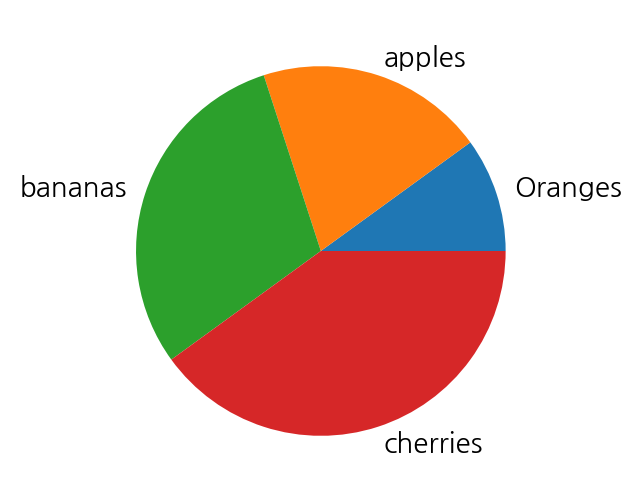

In [43]:
fruits = ['Oranges', 'apples', 'bananas', 'cherries']
plt.pie([10, 20, 30, 40], labels = fruits);

In [38]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


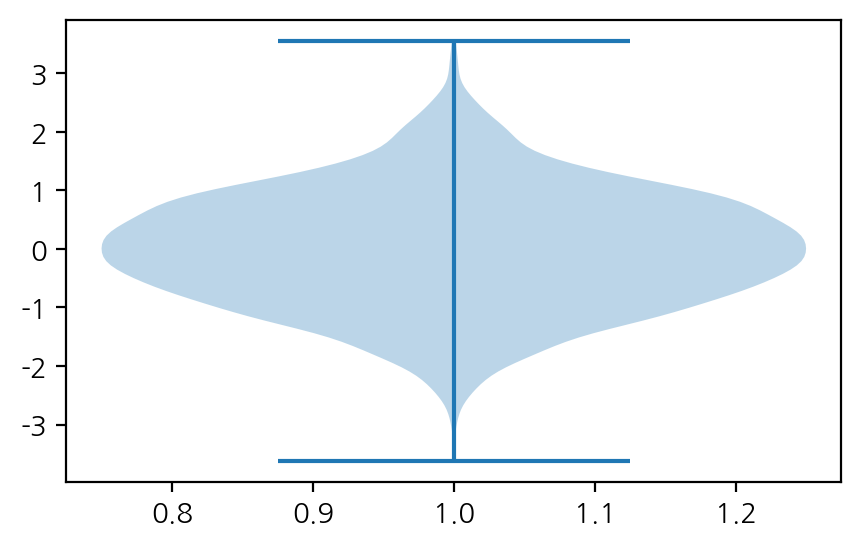

In [44]:
data = np.random.randn(2000)
plt.violinplot(data);

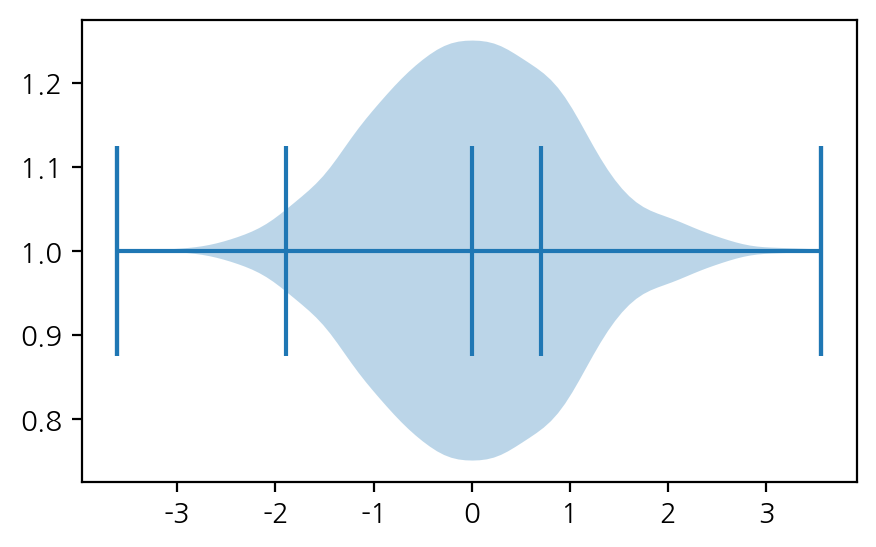

In [46]:
plt.violinplot(data, quantiles=[0, .025, .5, .75, 1], vert = False);

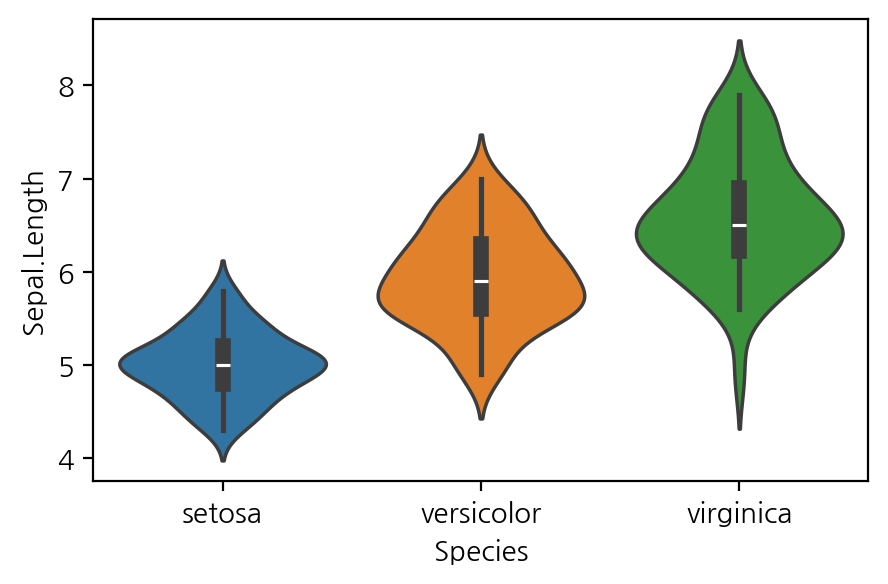

In [47]:
sns.violinplot(iris, x = 'Species', y = 'Sepal.Length', hue = 'Species');

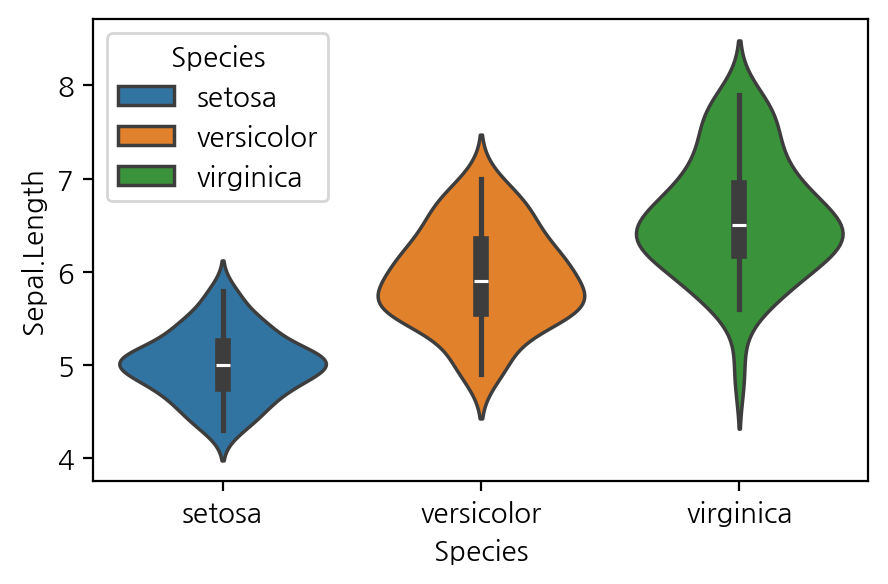

In [49]:
sns.violinplot(iris, x = 'Species', y = 'Sepal.Length', hue = 'Species', legend = 'full');

In [39]:
mincars = mtc.iloc[:, :4]
mincars.head()

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


In [40]:
print(mtc.columns[:4])

Index(['mpg', 'cyl', 'disp', 'hp'], dtype='object')


In [41]:
print(mtc.columns[:4].to_list())

['mpg', 'cyl', 'disp', 'hp']


In [42]:
mincars = mtc[mtc.columns[:4].to_list()]
mincars.head(3)

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93


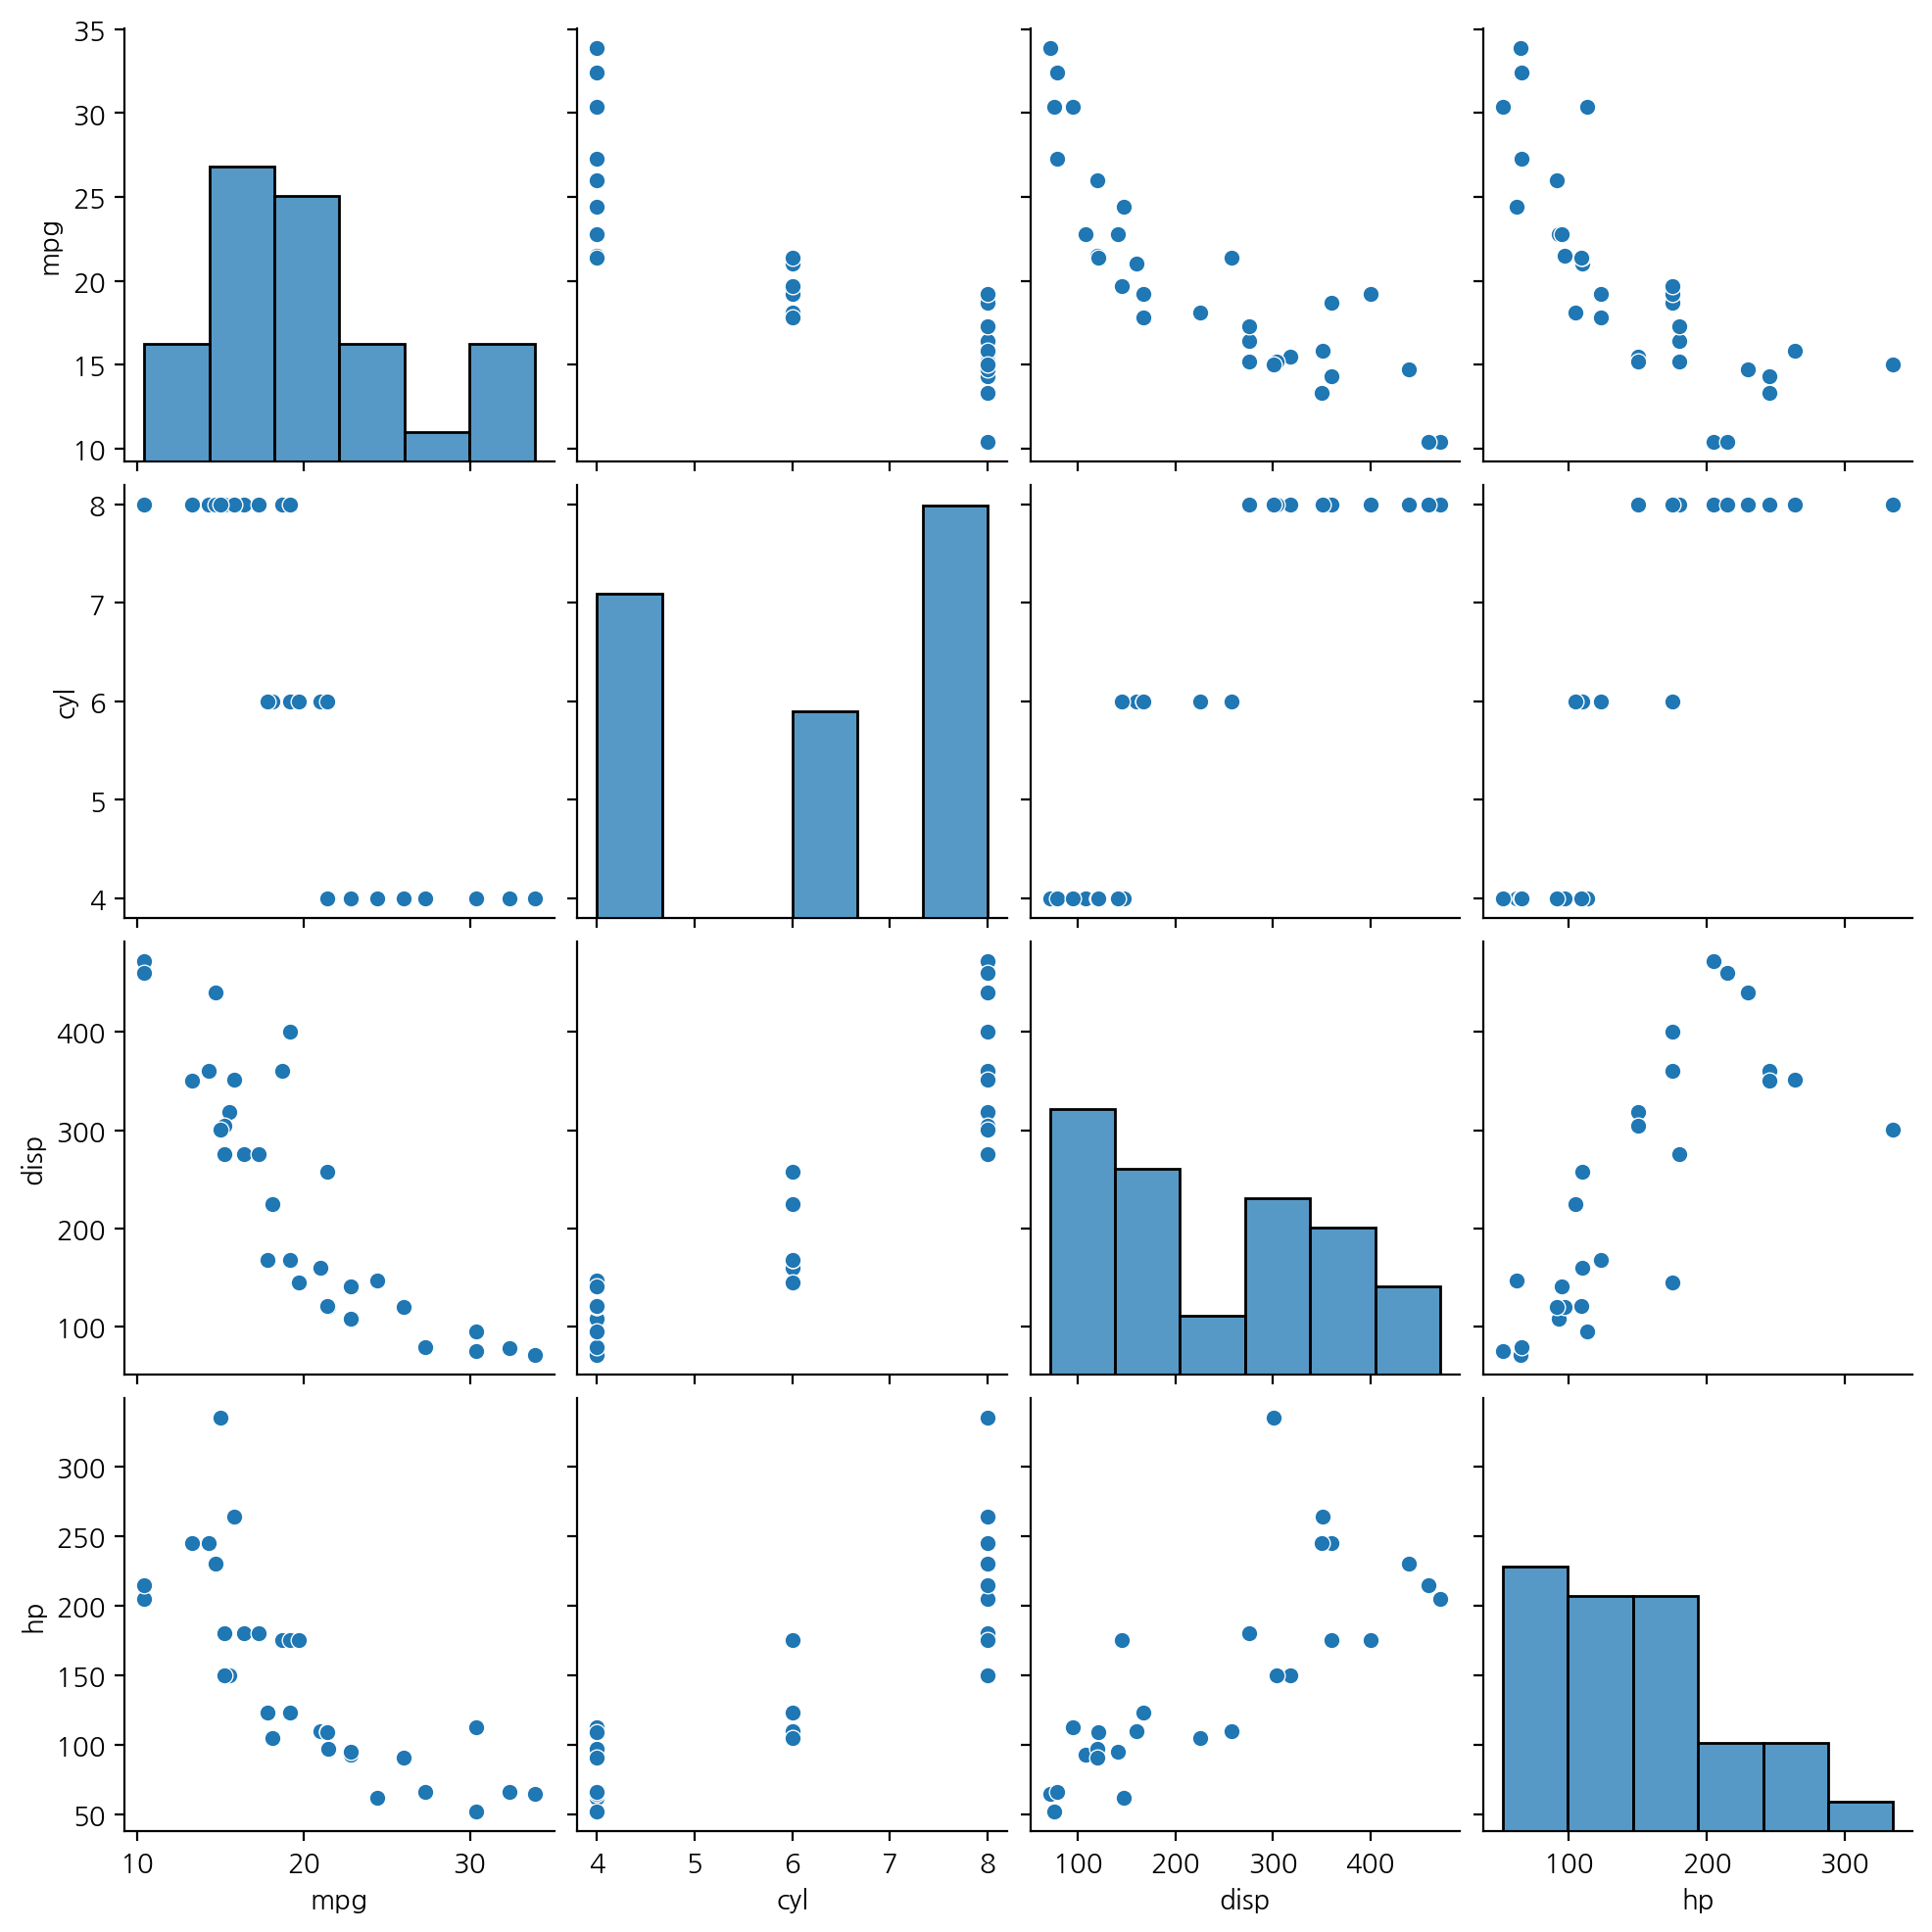

In [50]:
sns.pairplot(mincars)

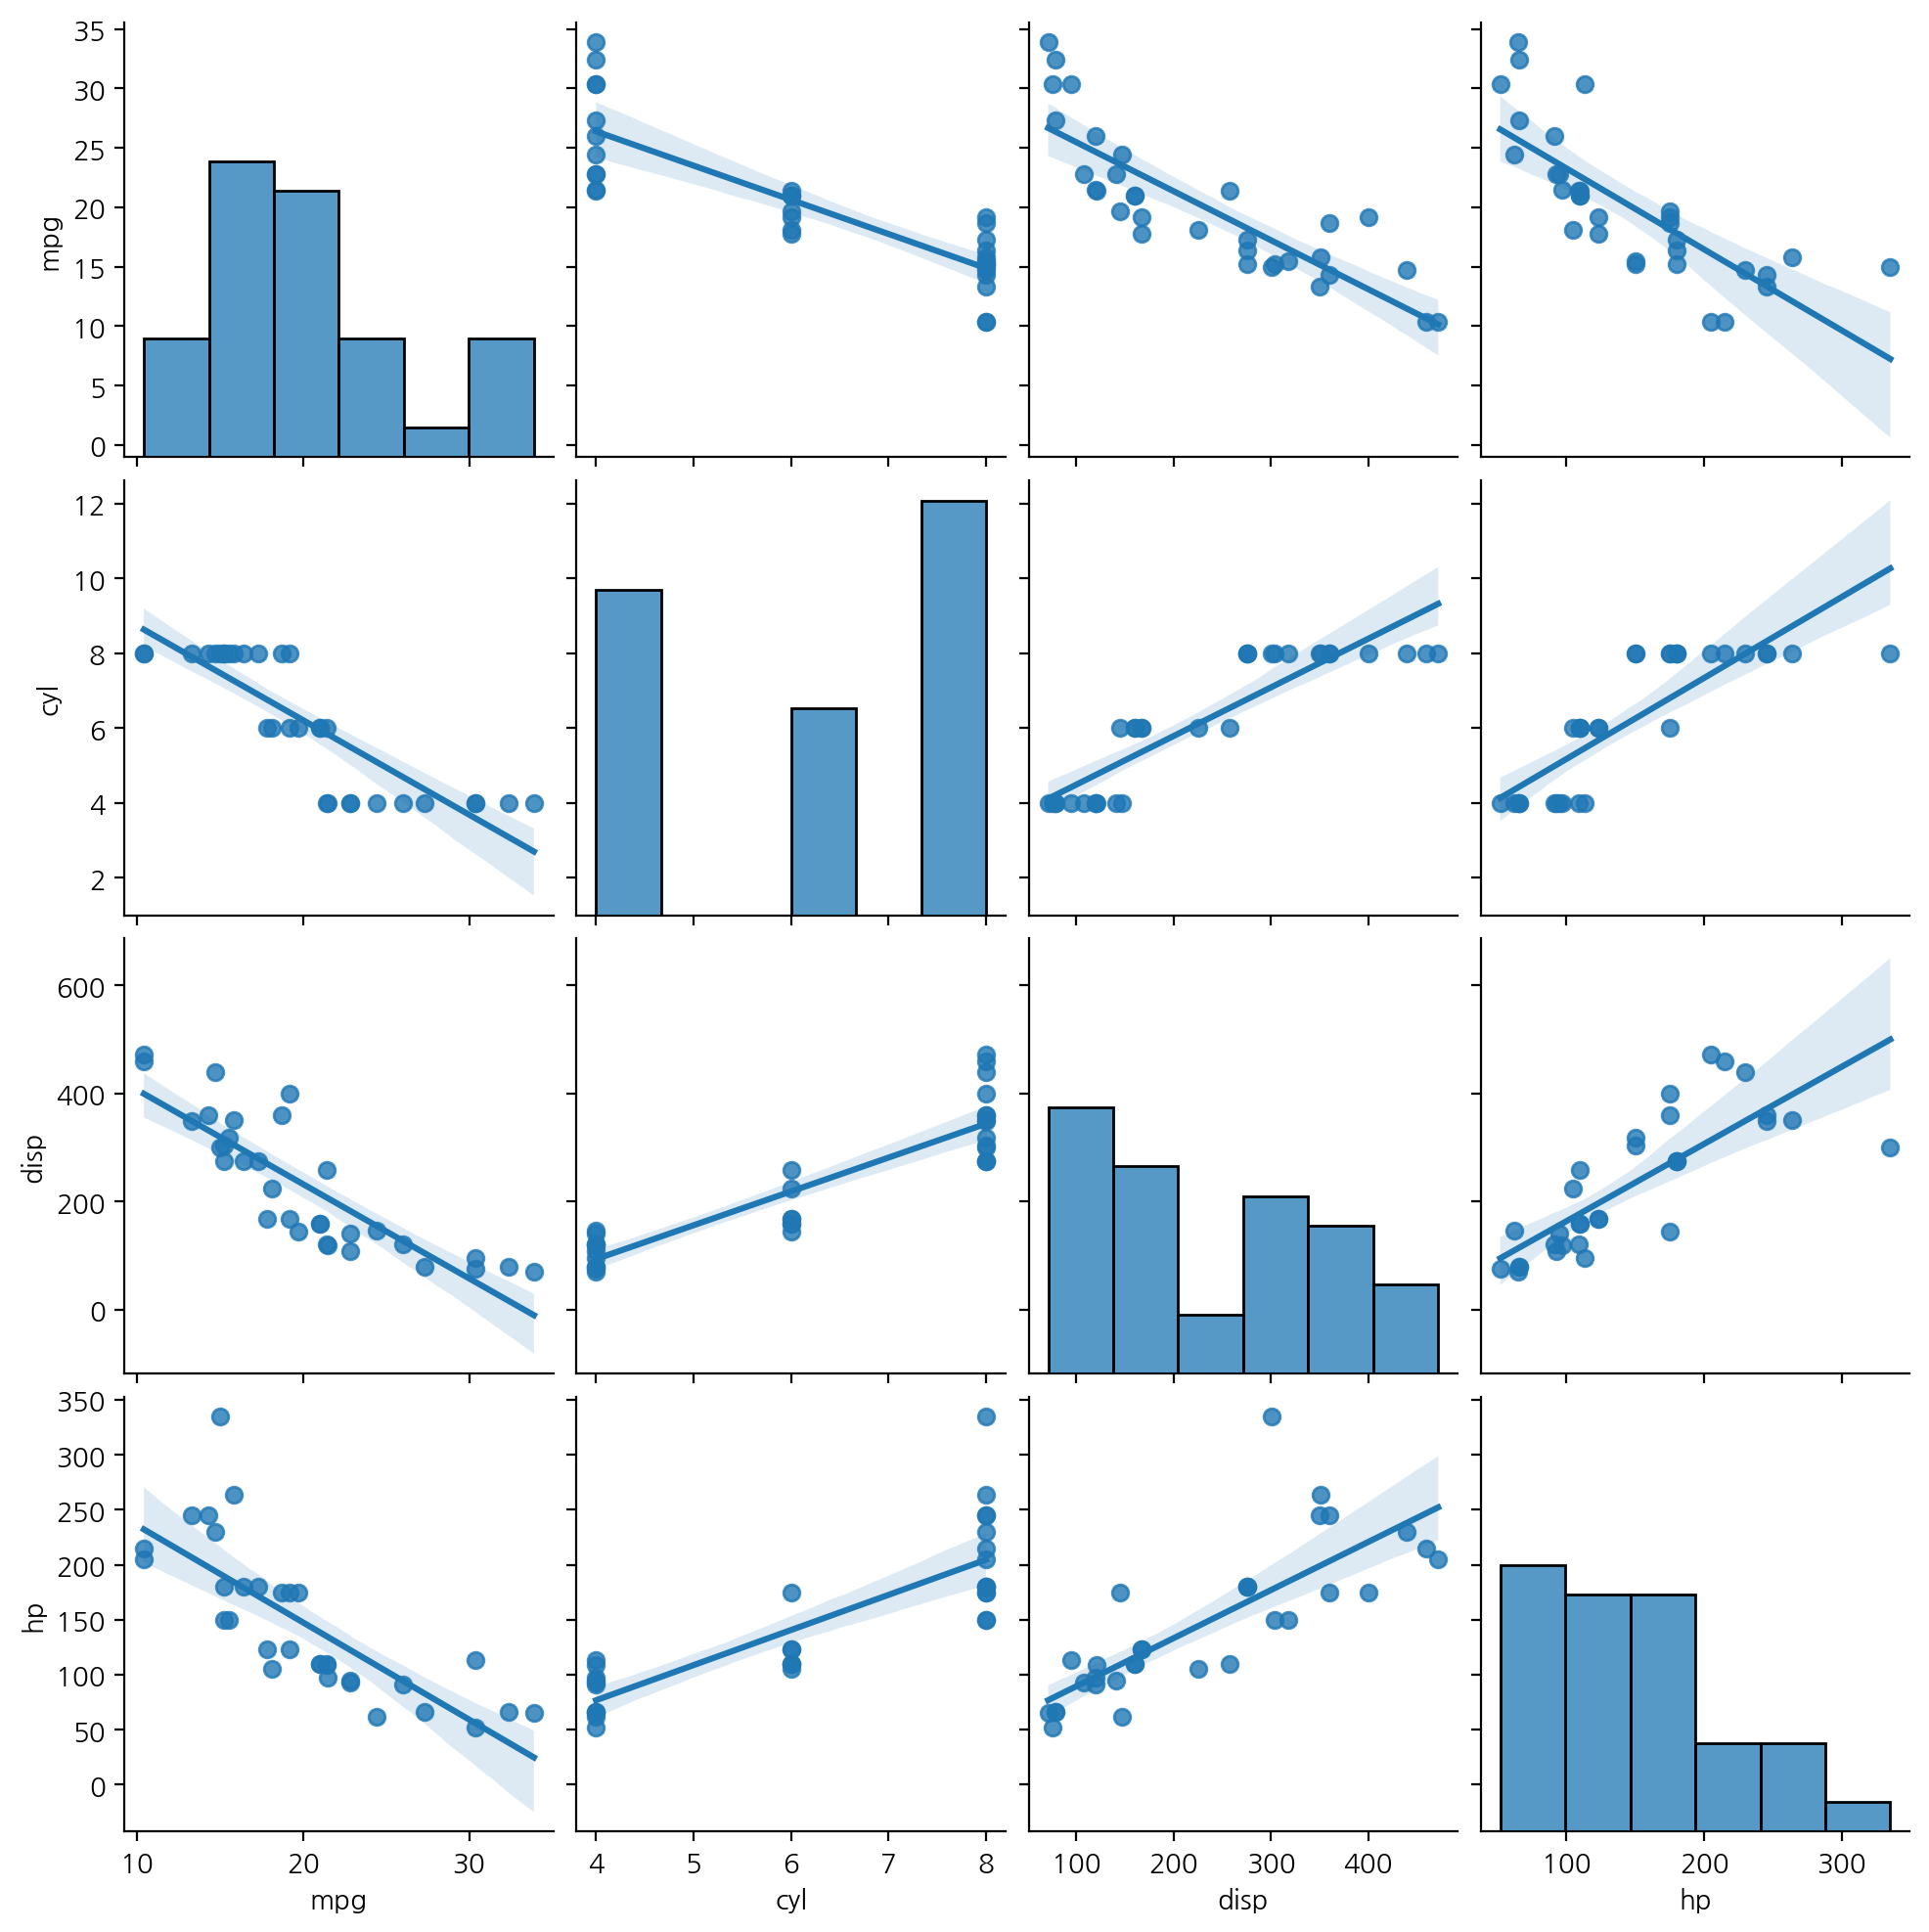

In [55]:
sns.pairplot(mincars, kind = 'reg');

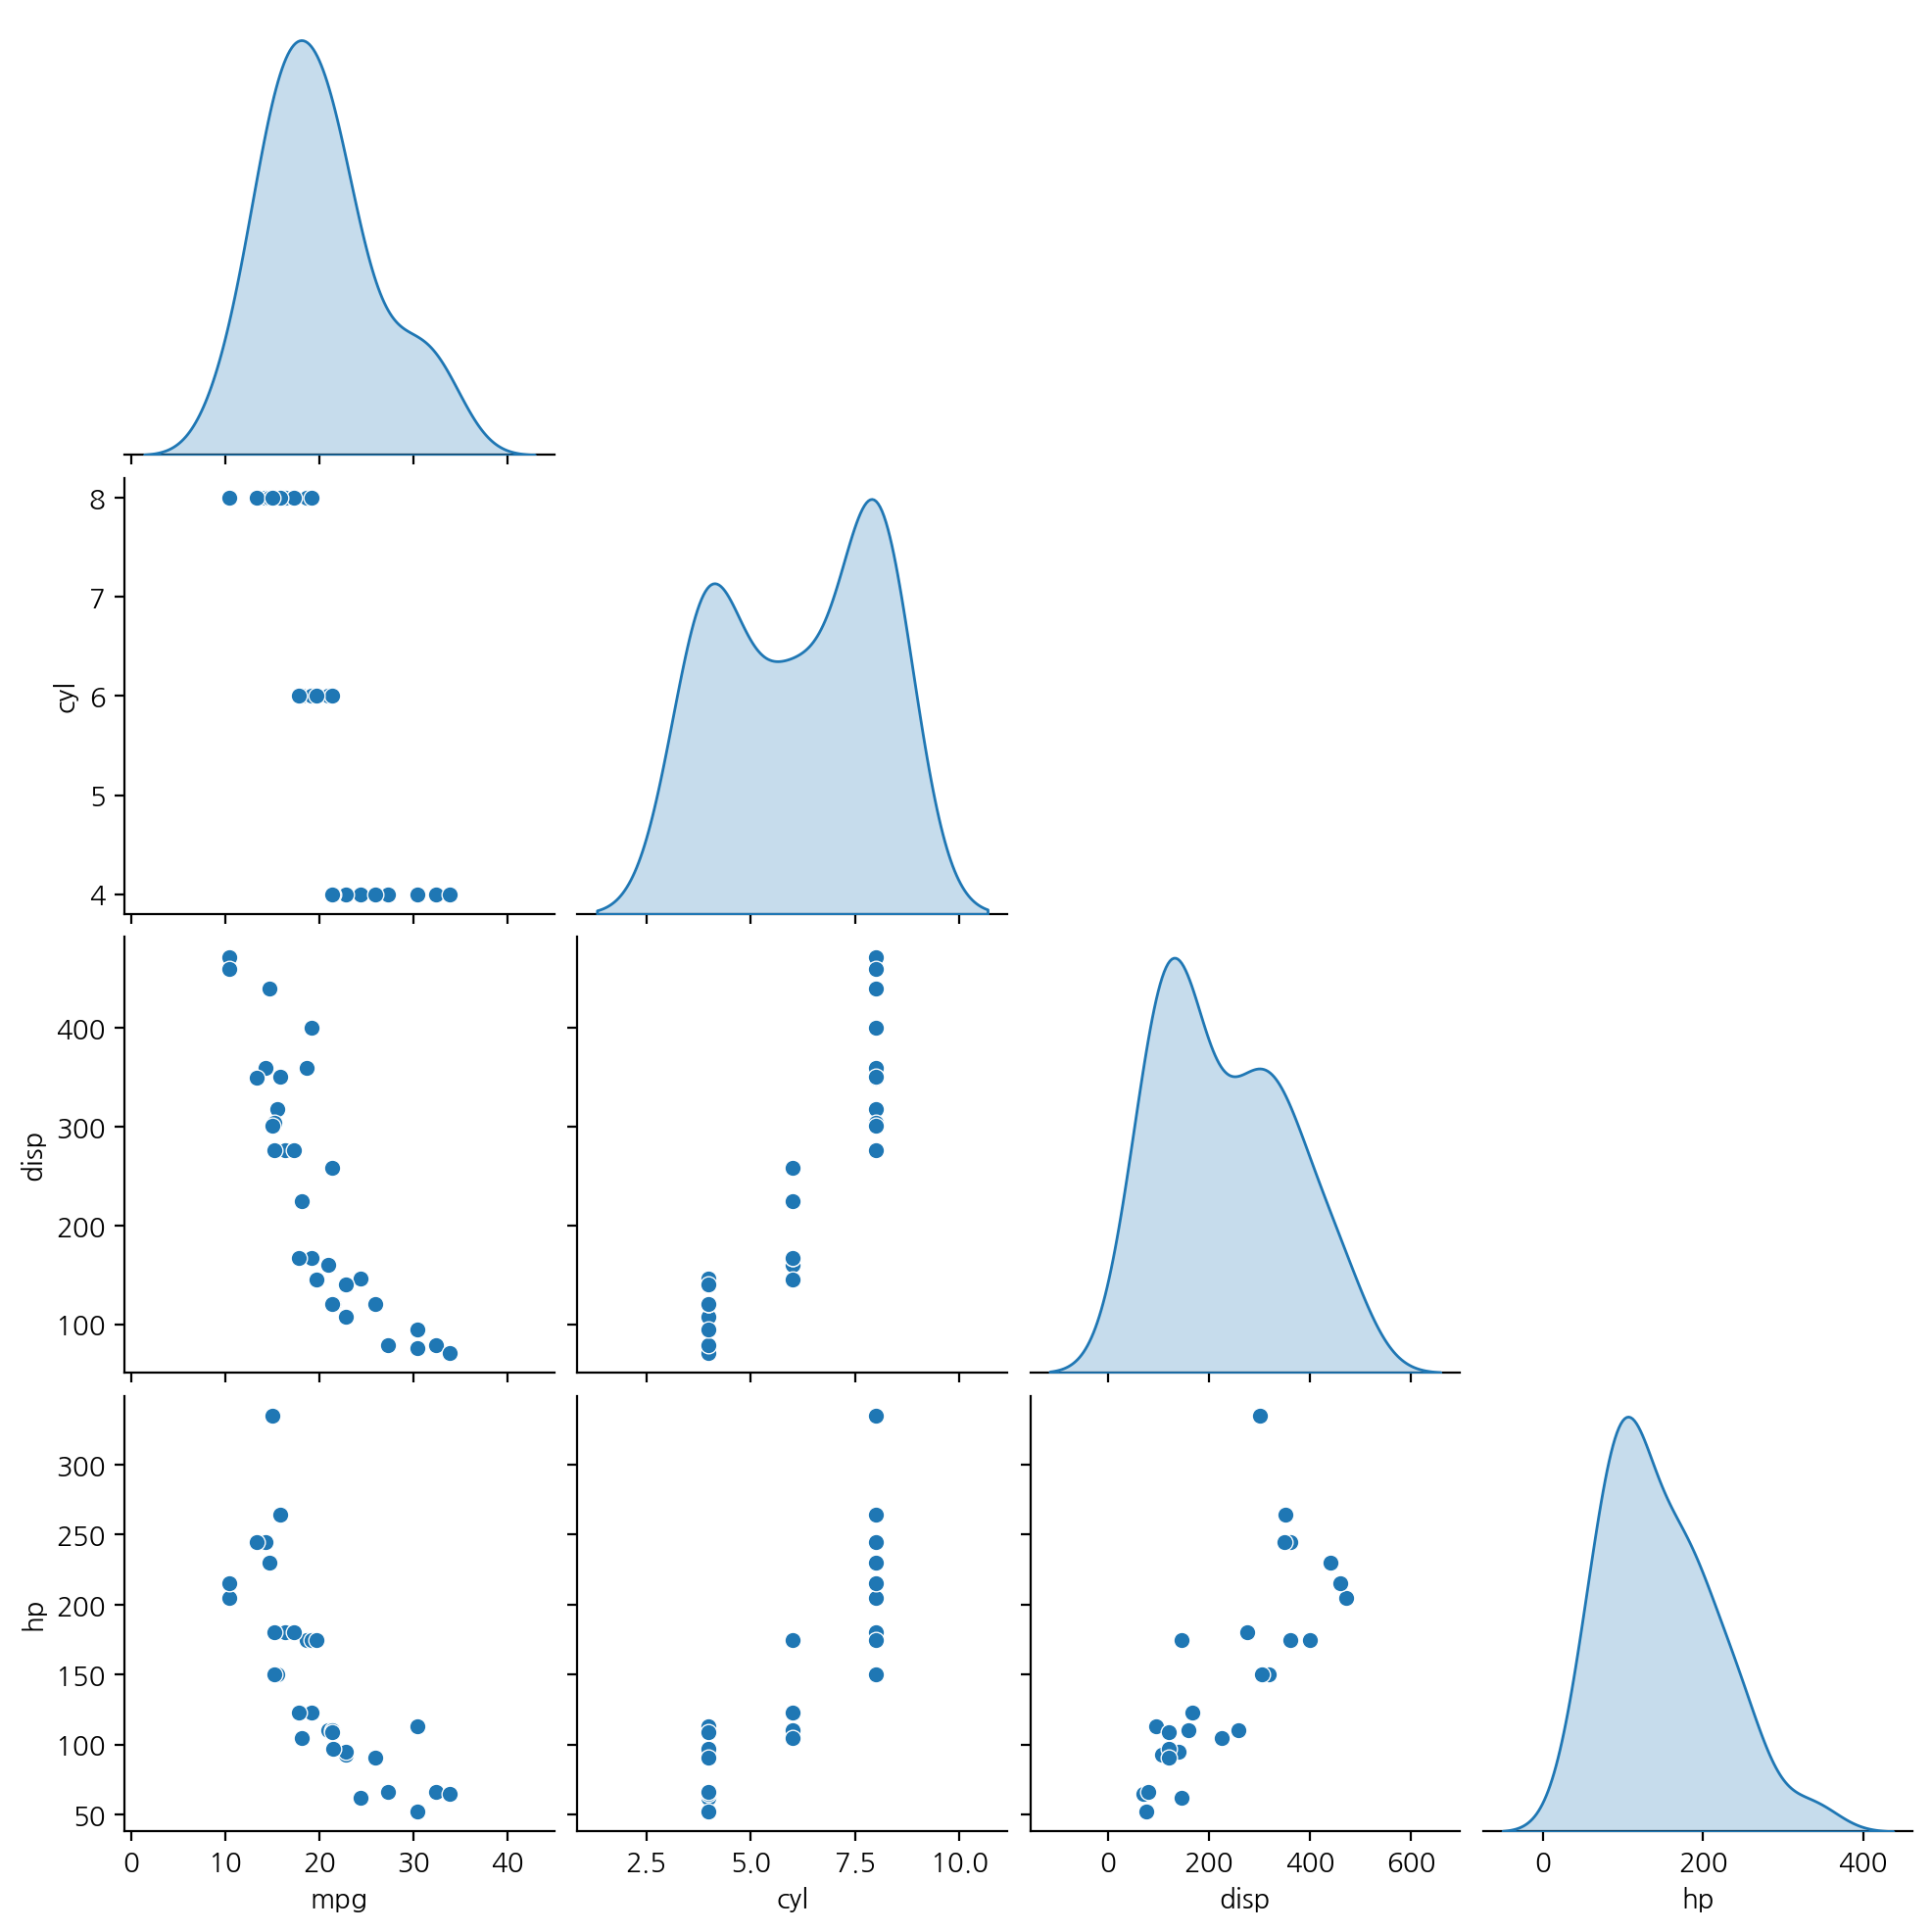

In [53]:
sns.pairplot(mincars, diag_kind = 'kde', corner = True);

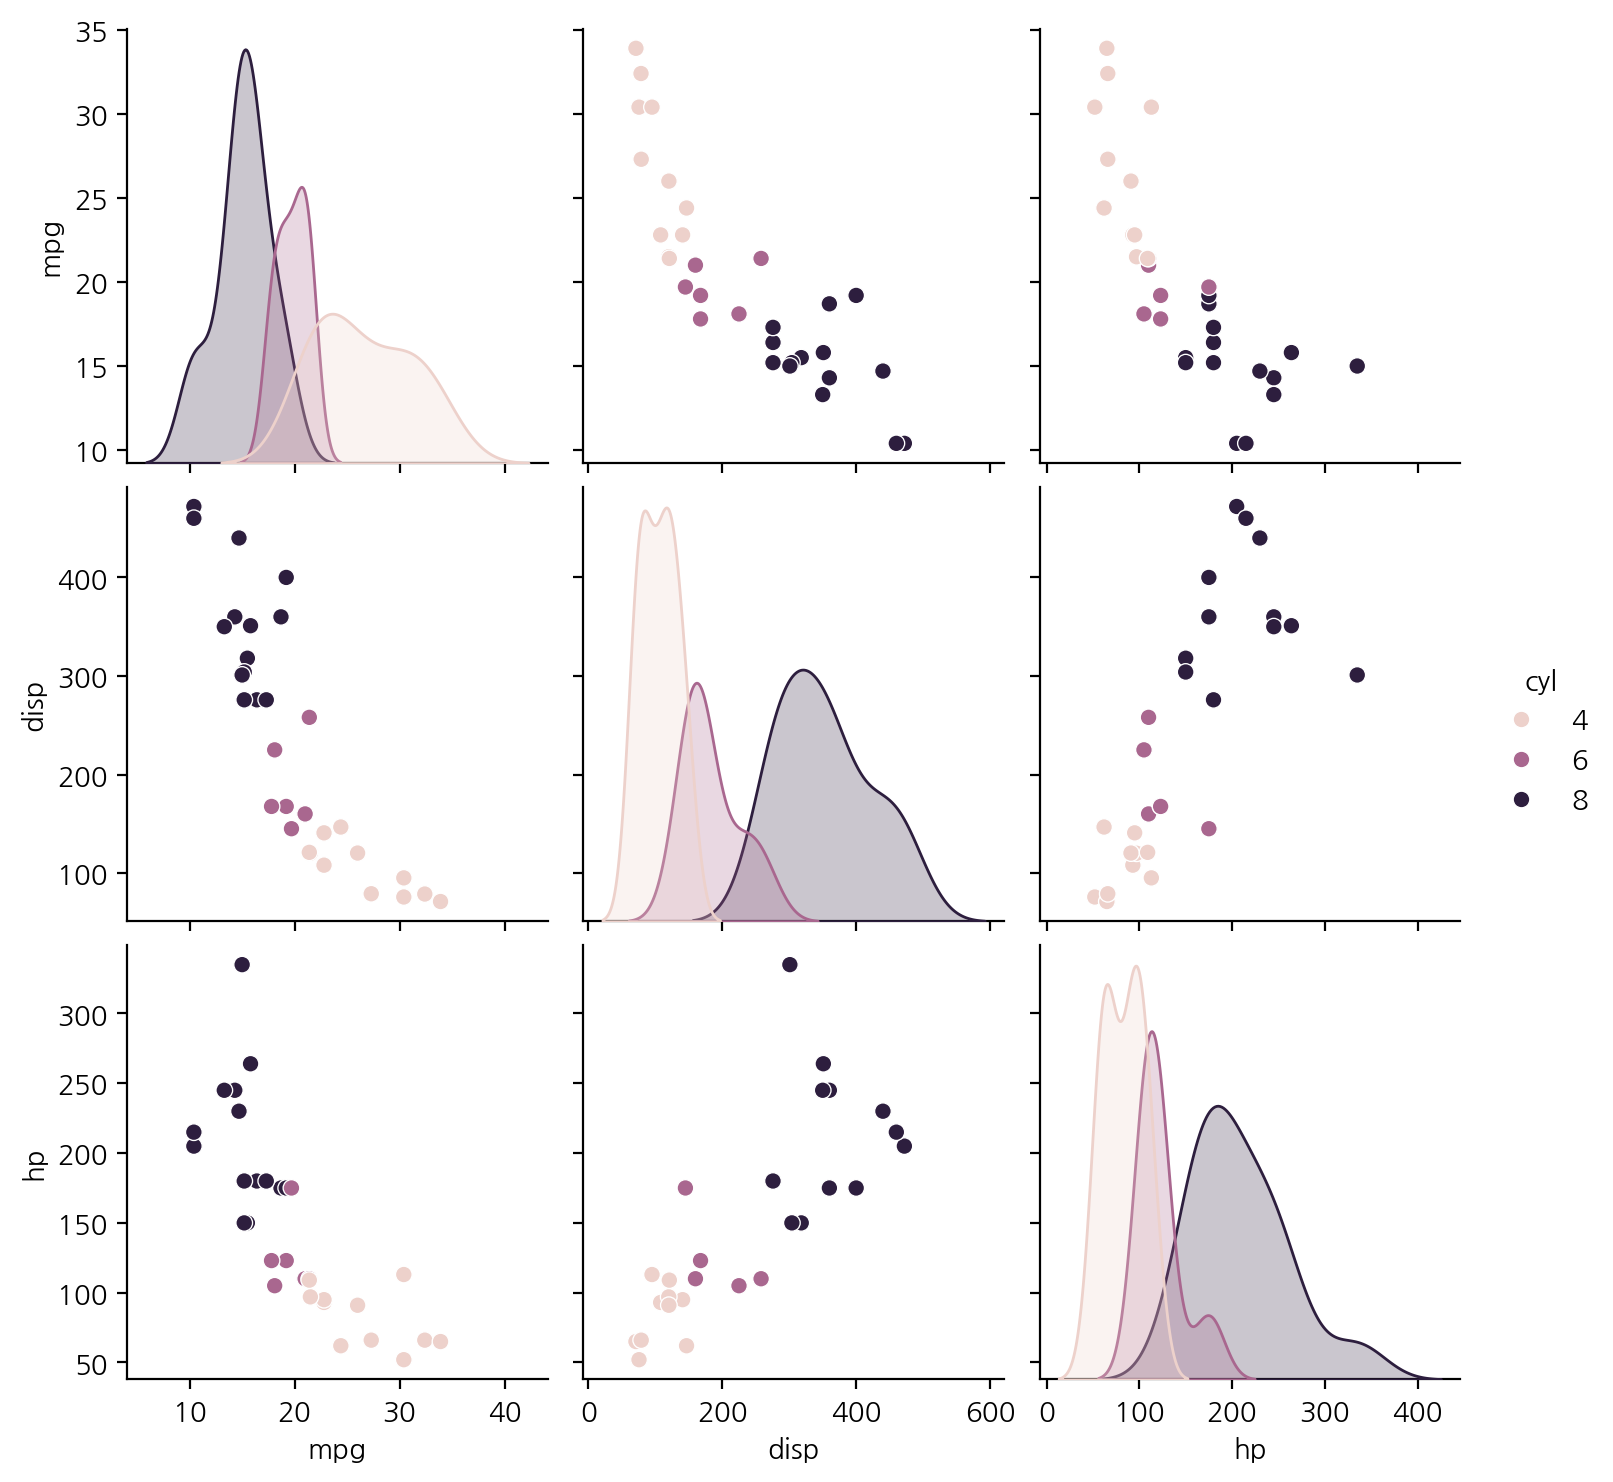

In [54]:
sns.pairplot(mincars, hue='cyl');

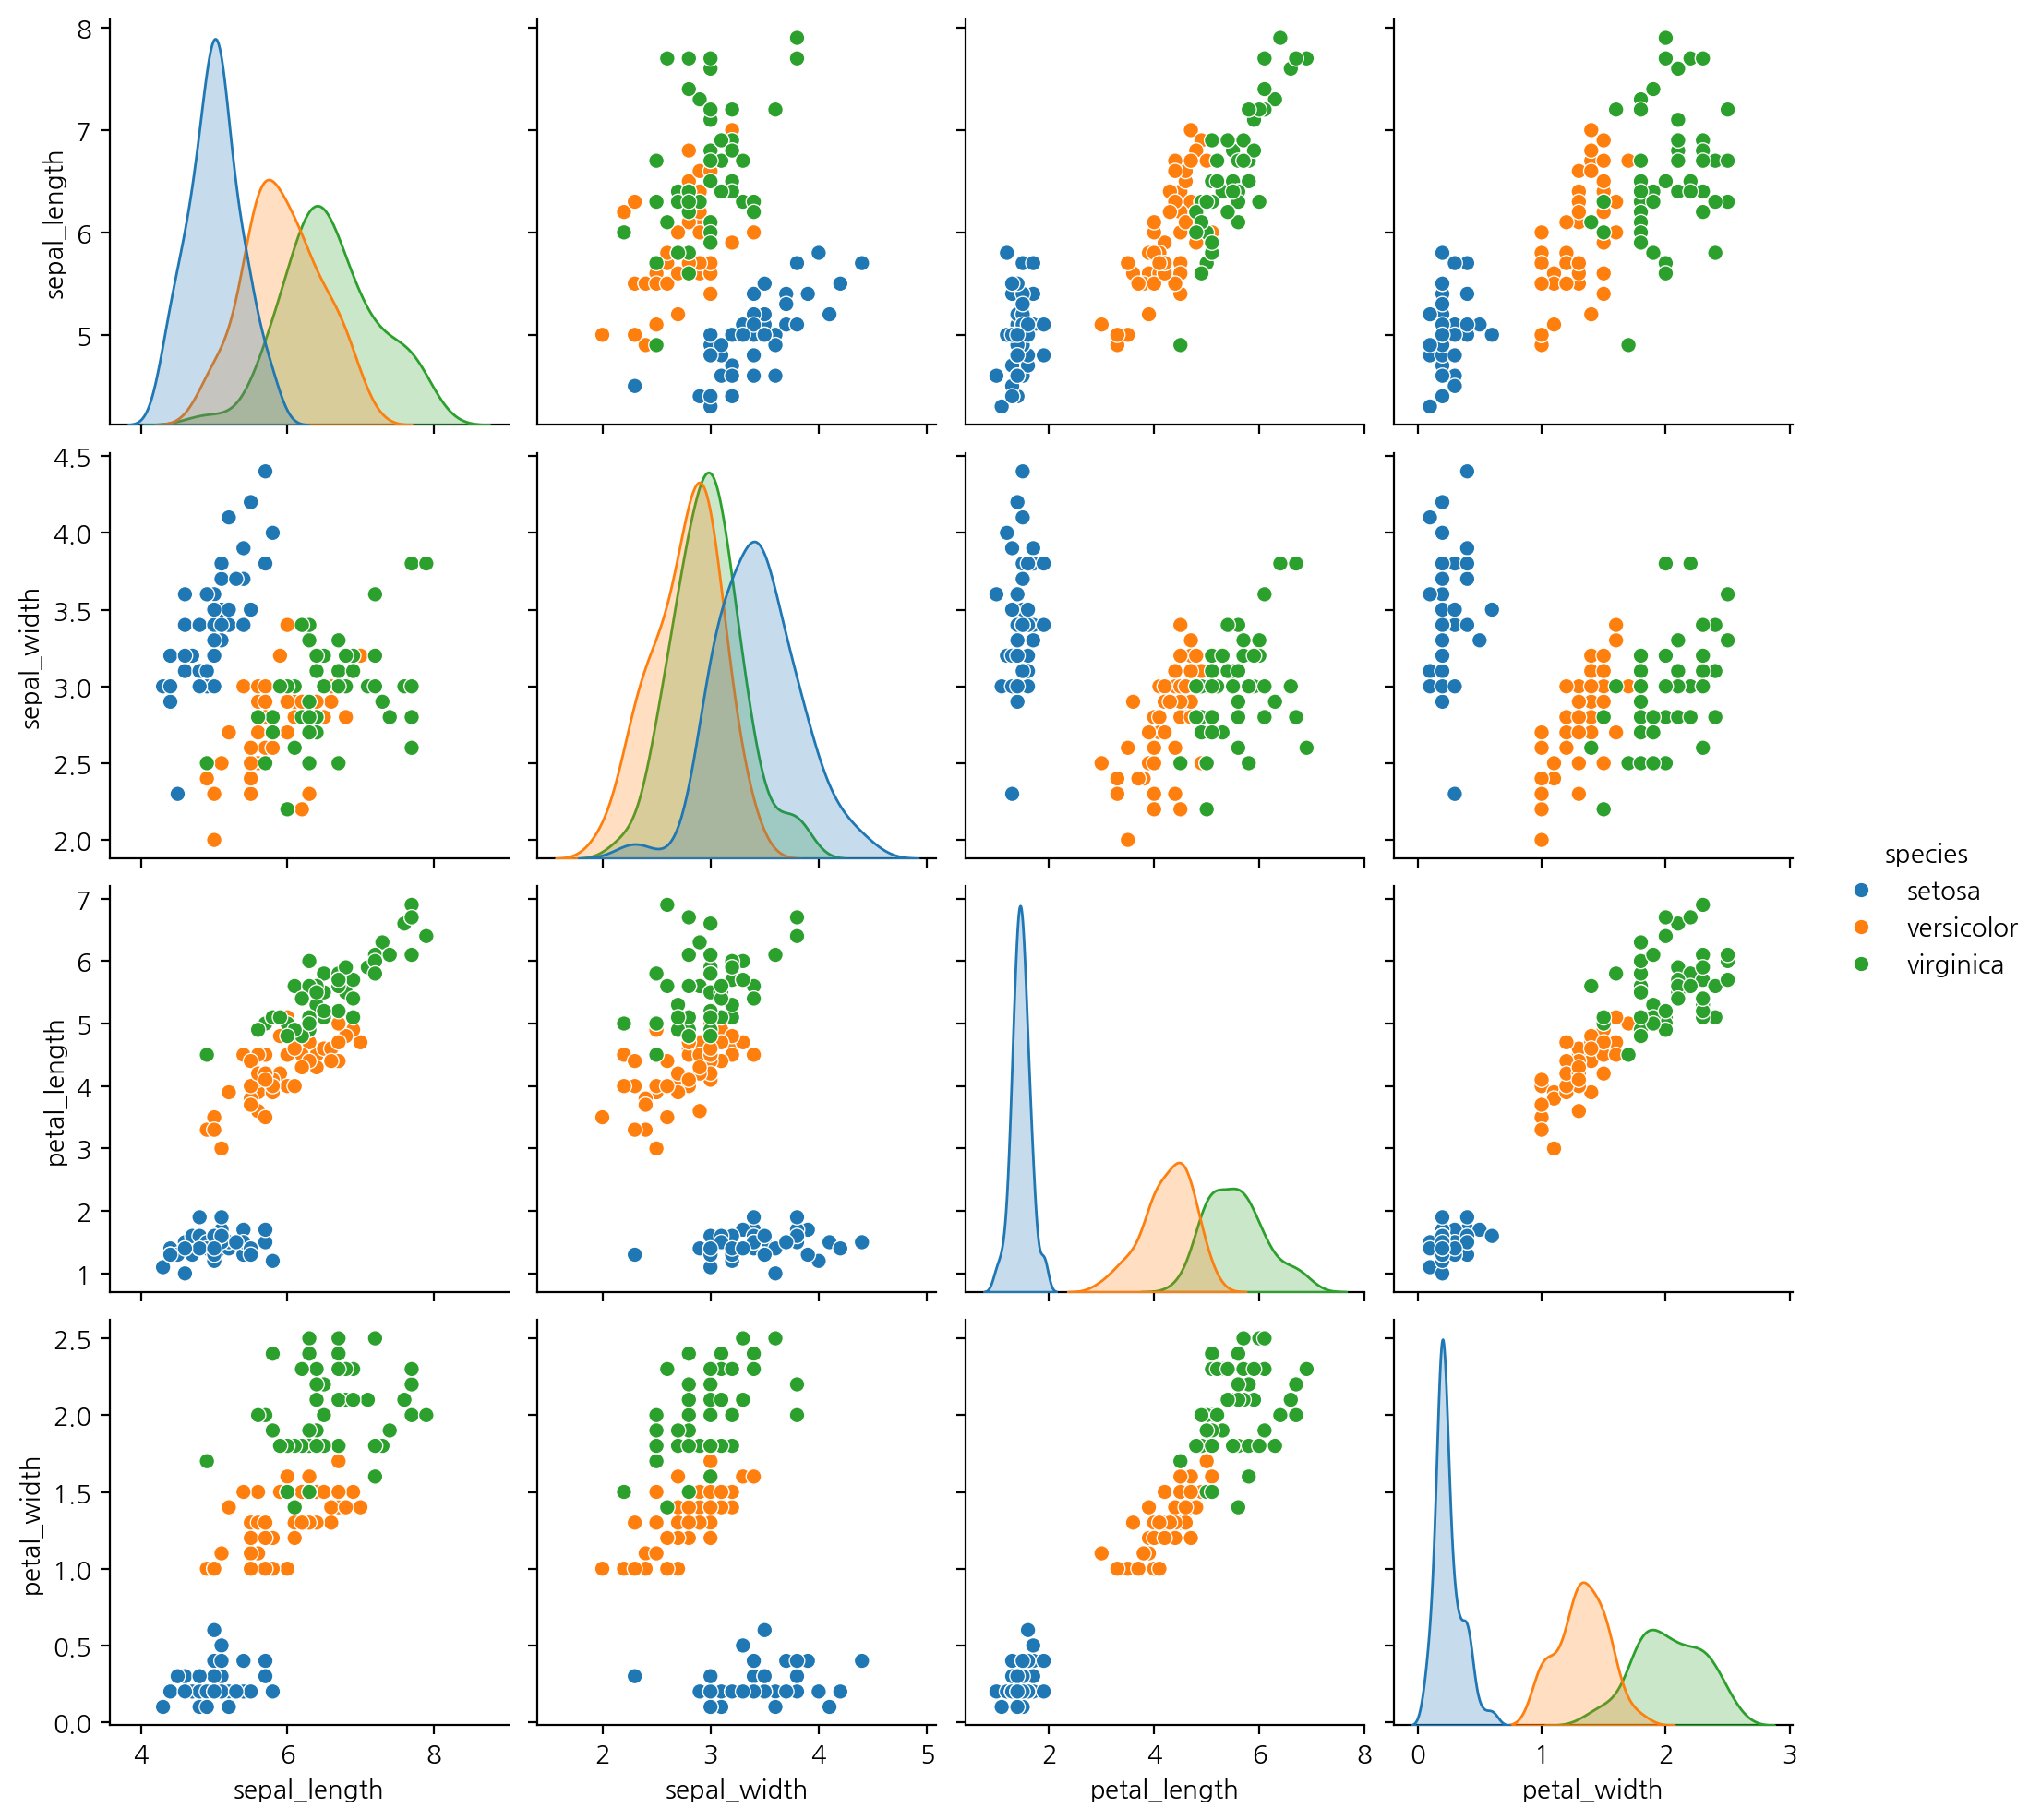

In [70]:
sns.pairplot(iris, hue='species')

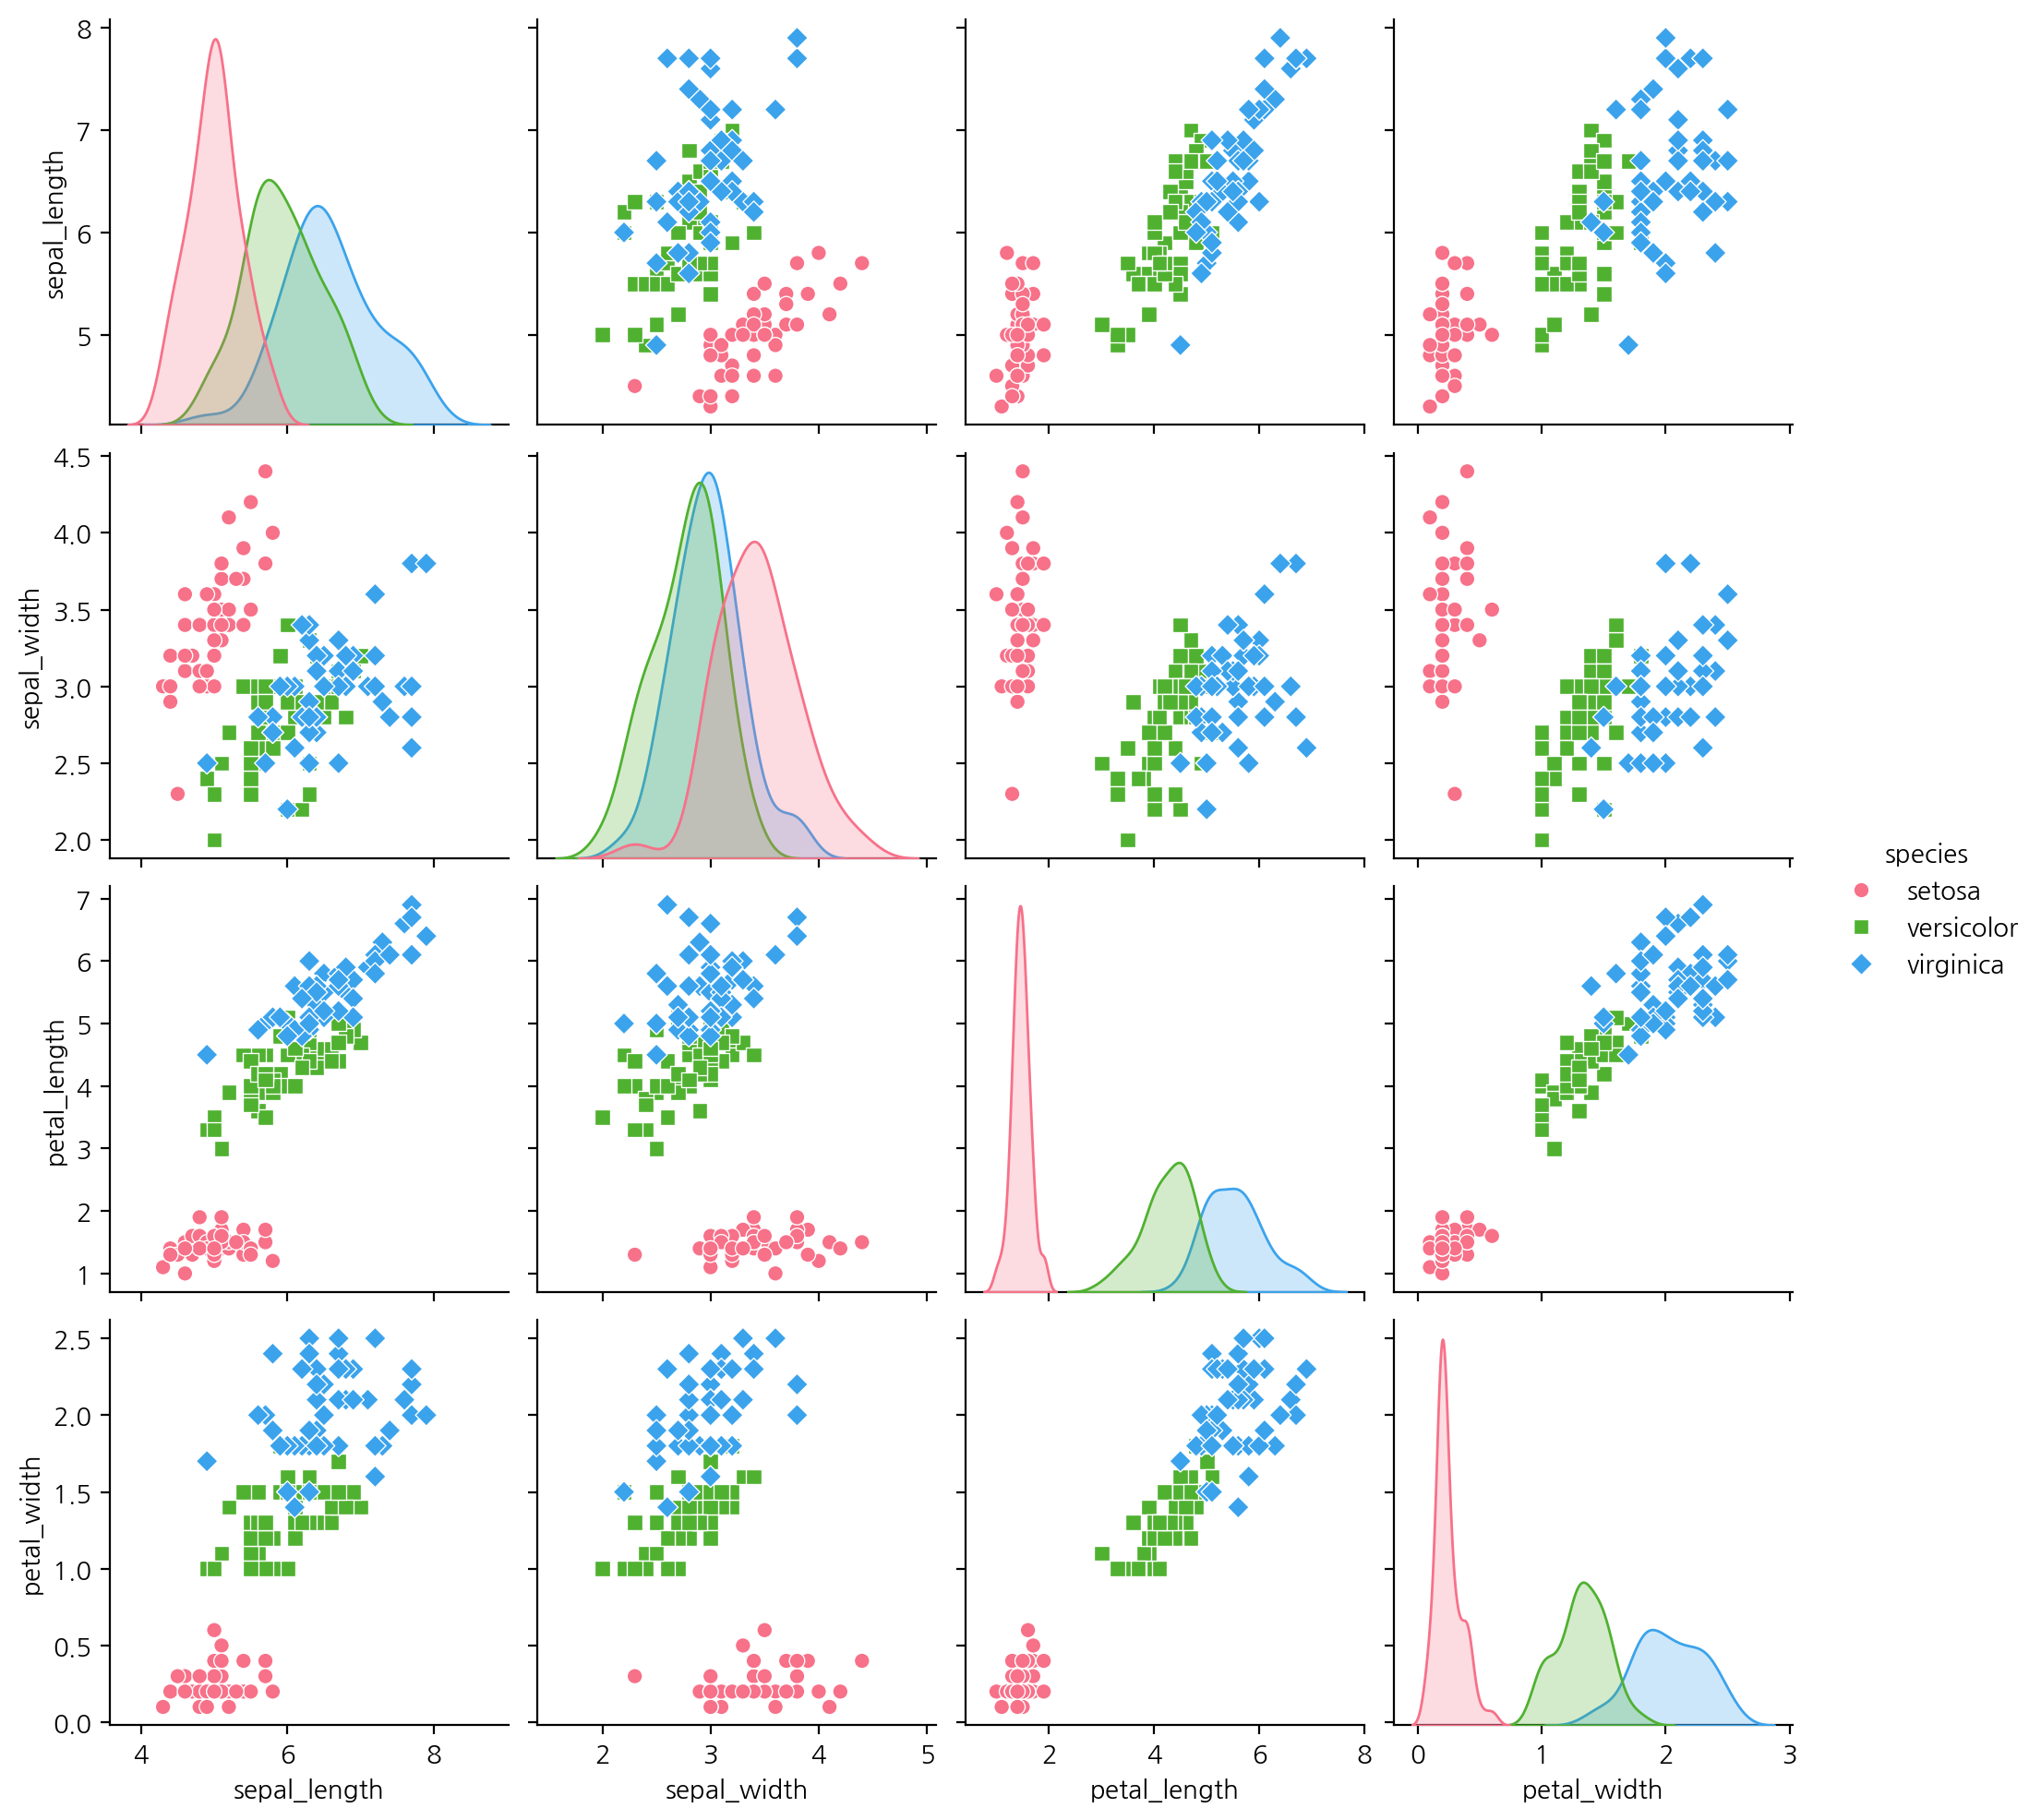

In [71]:
sns.pairplot(iris, hue="species", palette="husl", markers=["o", "s", "D"]);

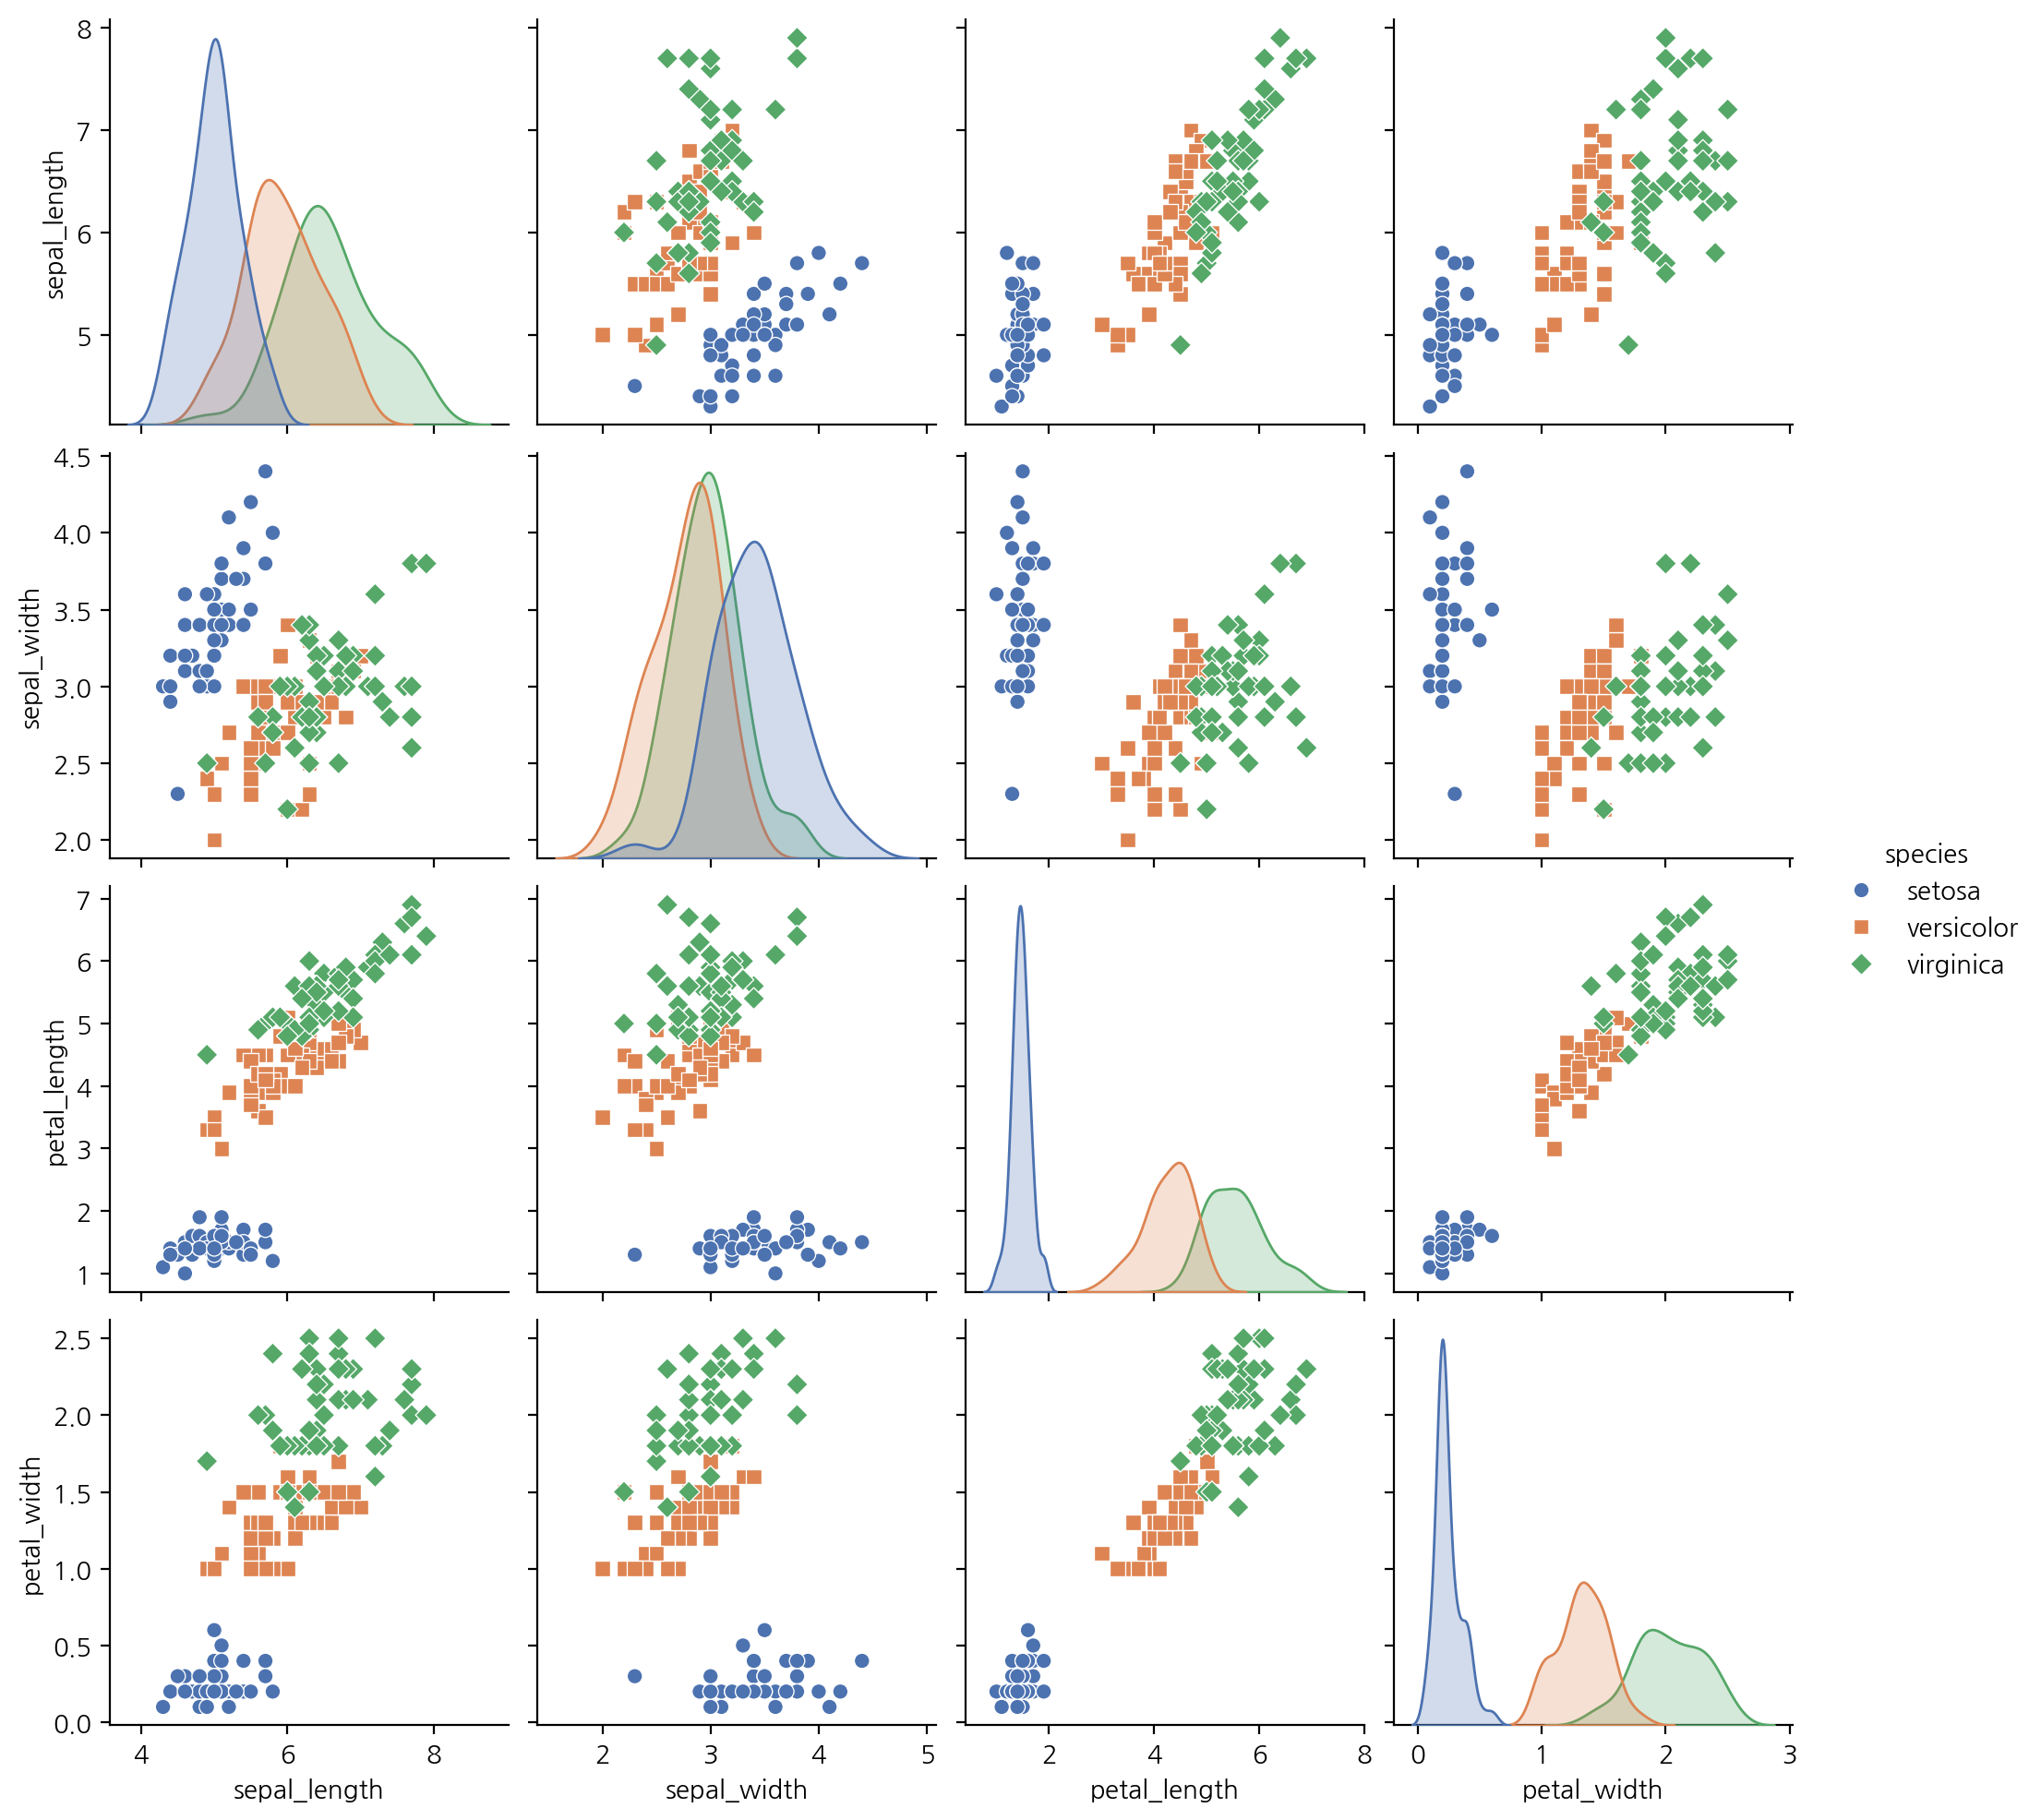

In [72]:
sns.pairplot(iris, hue="species", palette="deep", markers=["o", "s", "D"]);

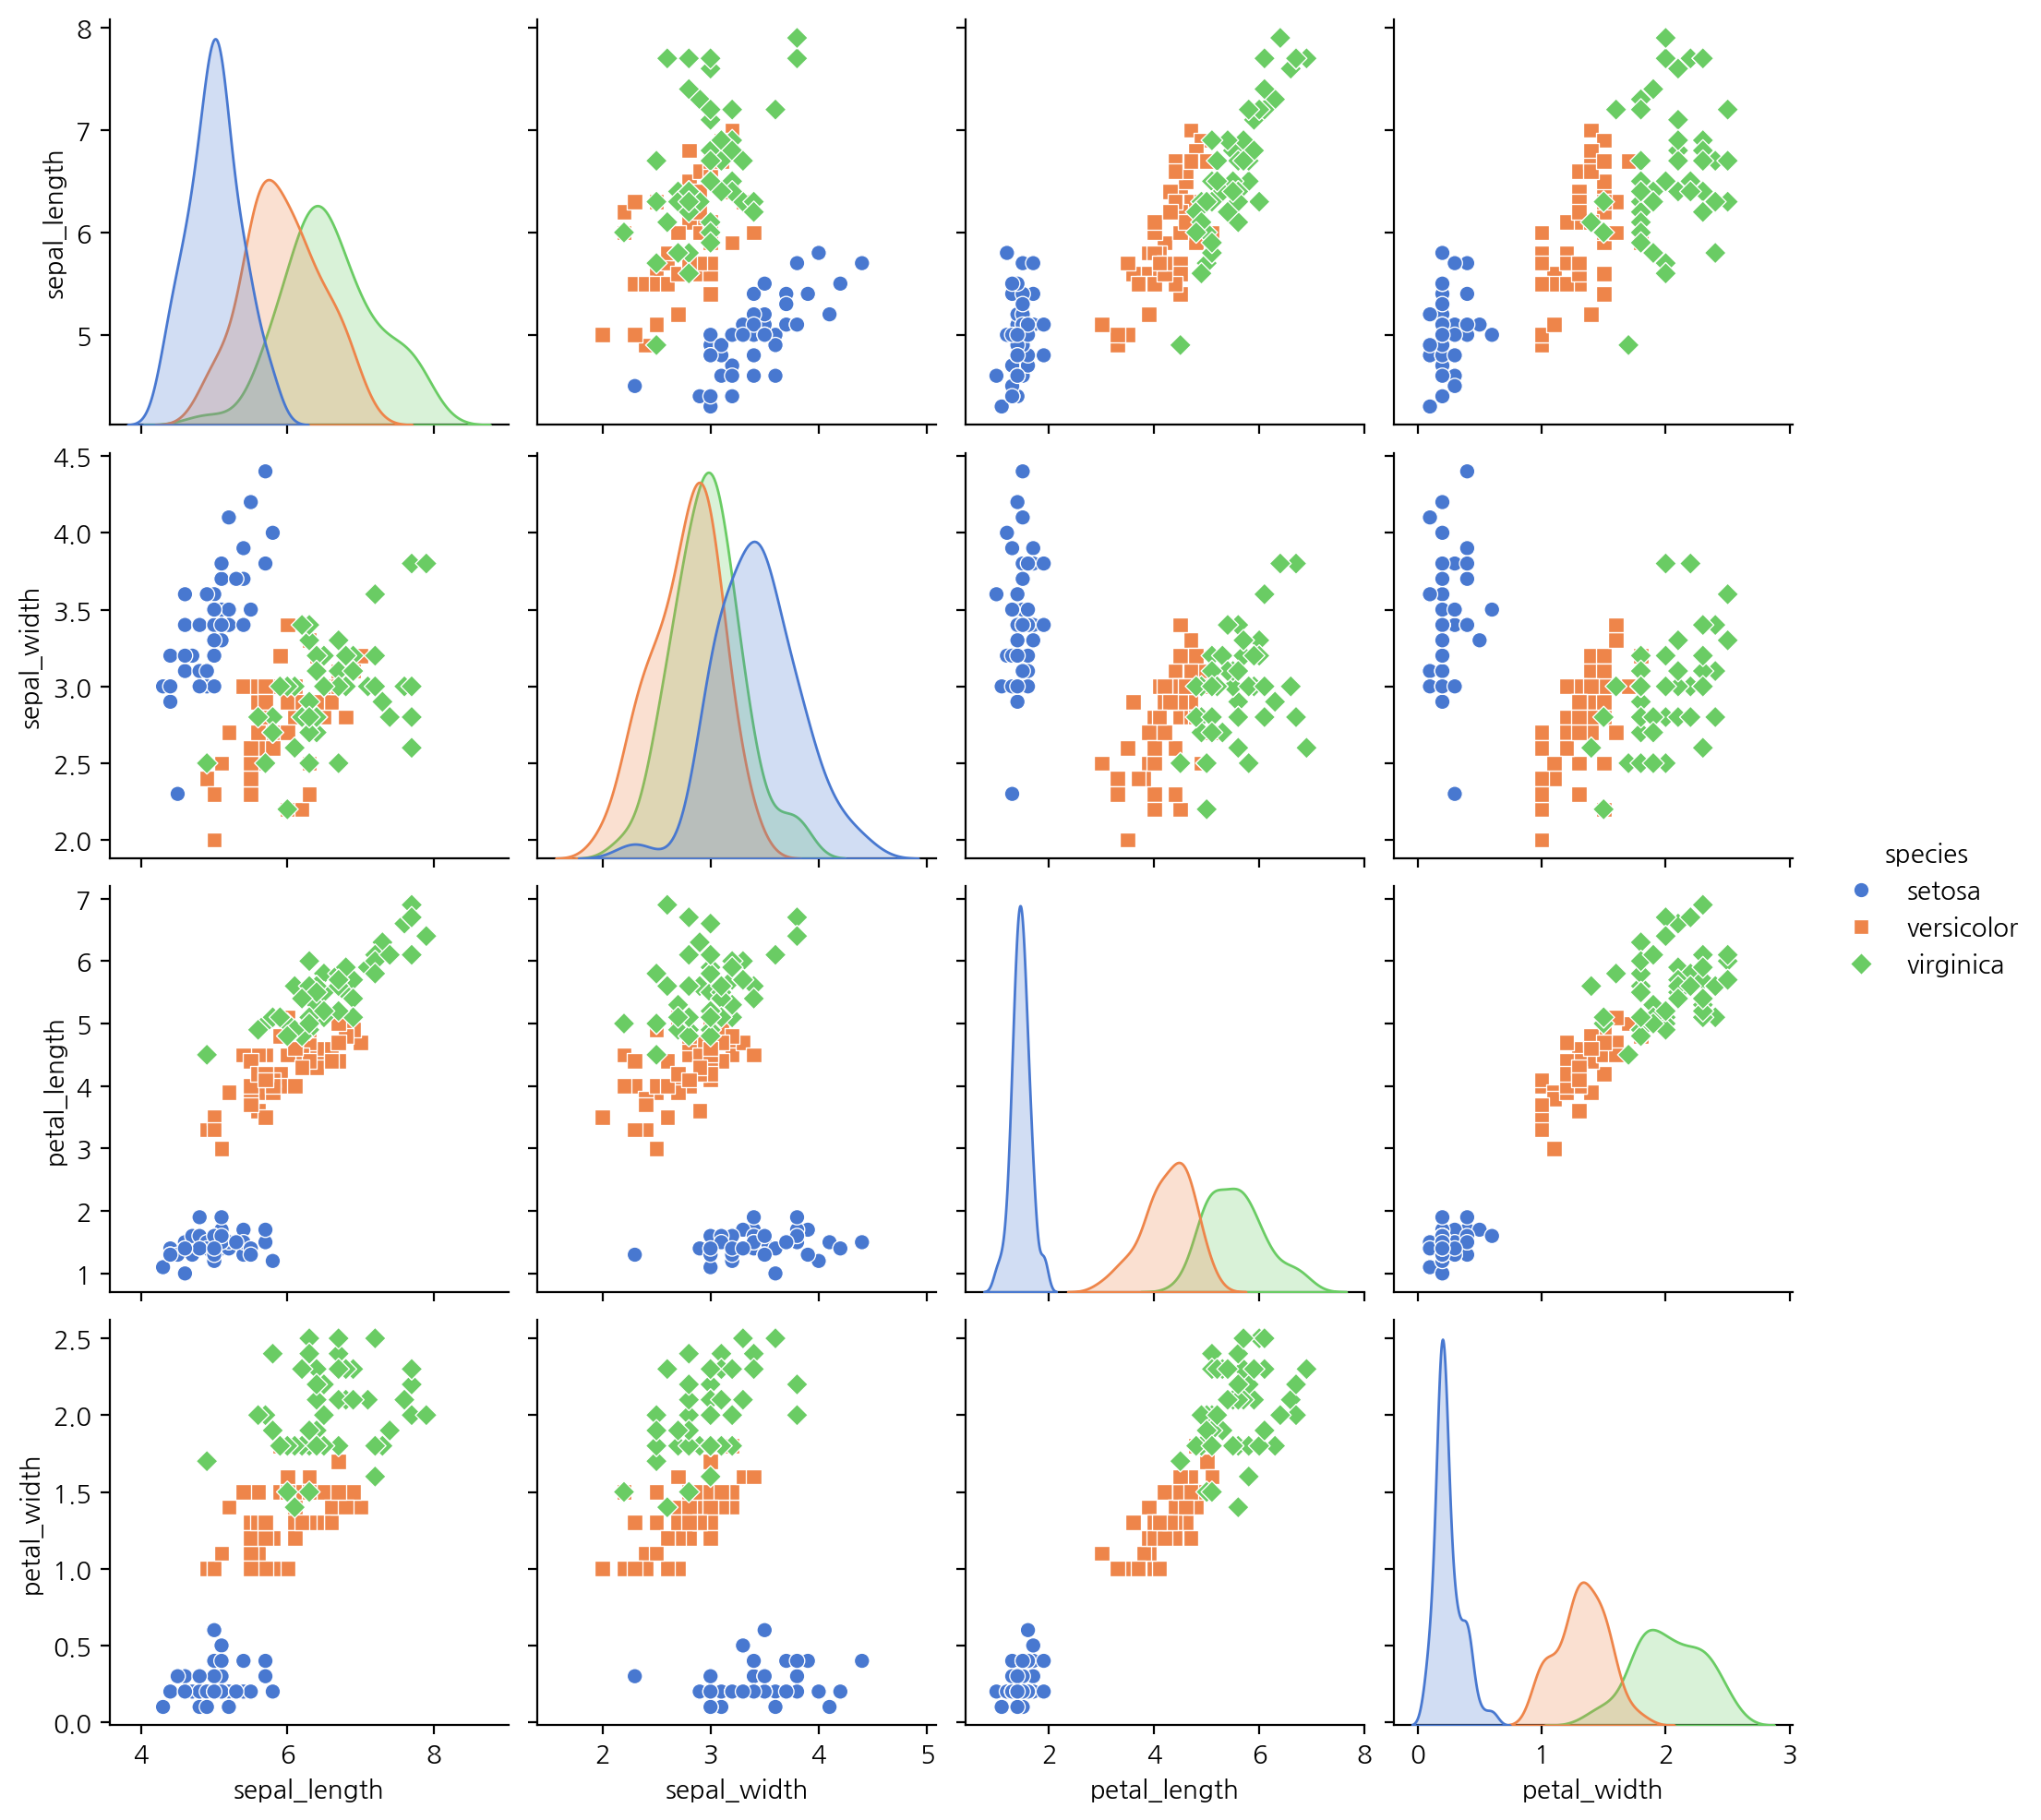

In [73]:
sns.pairplot(iris, hue="species", palette="muted", markers=["o", "s", "D"]);

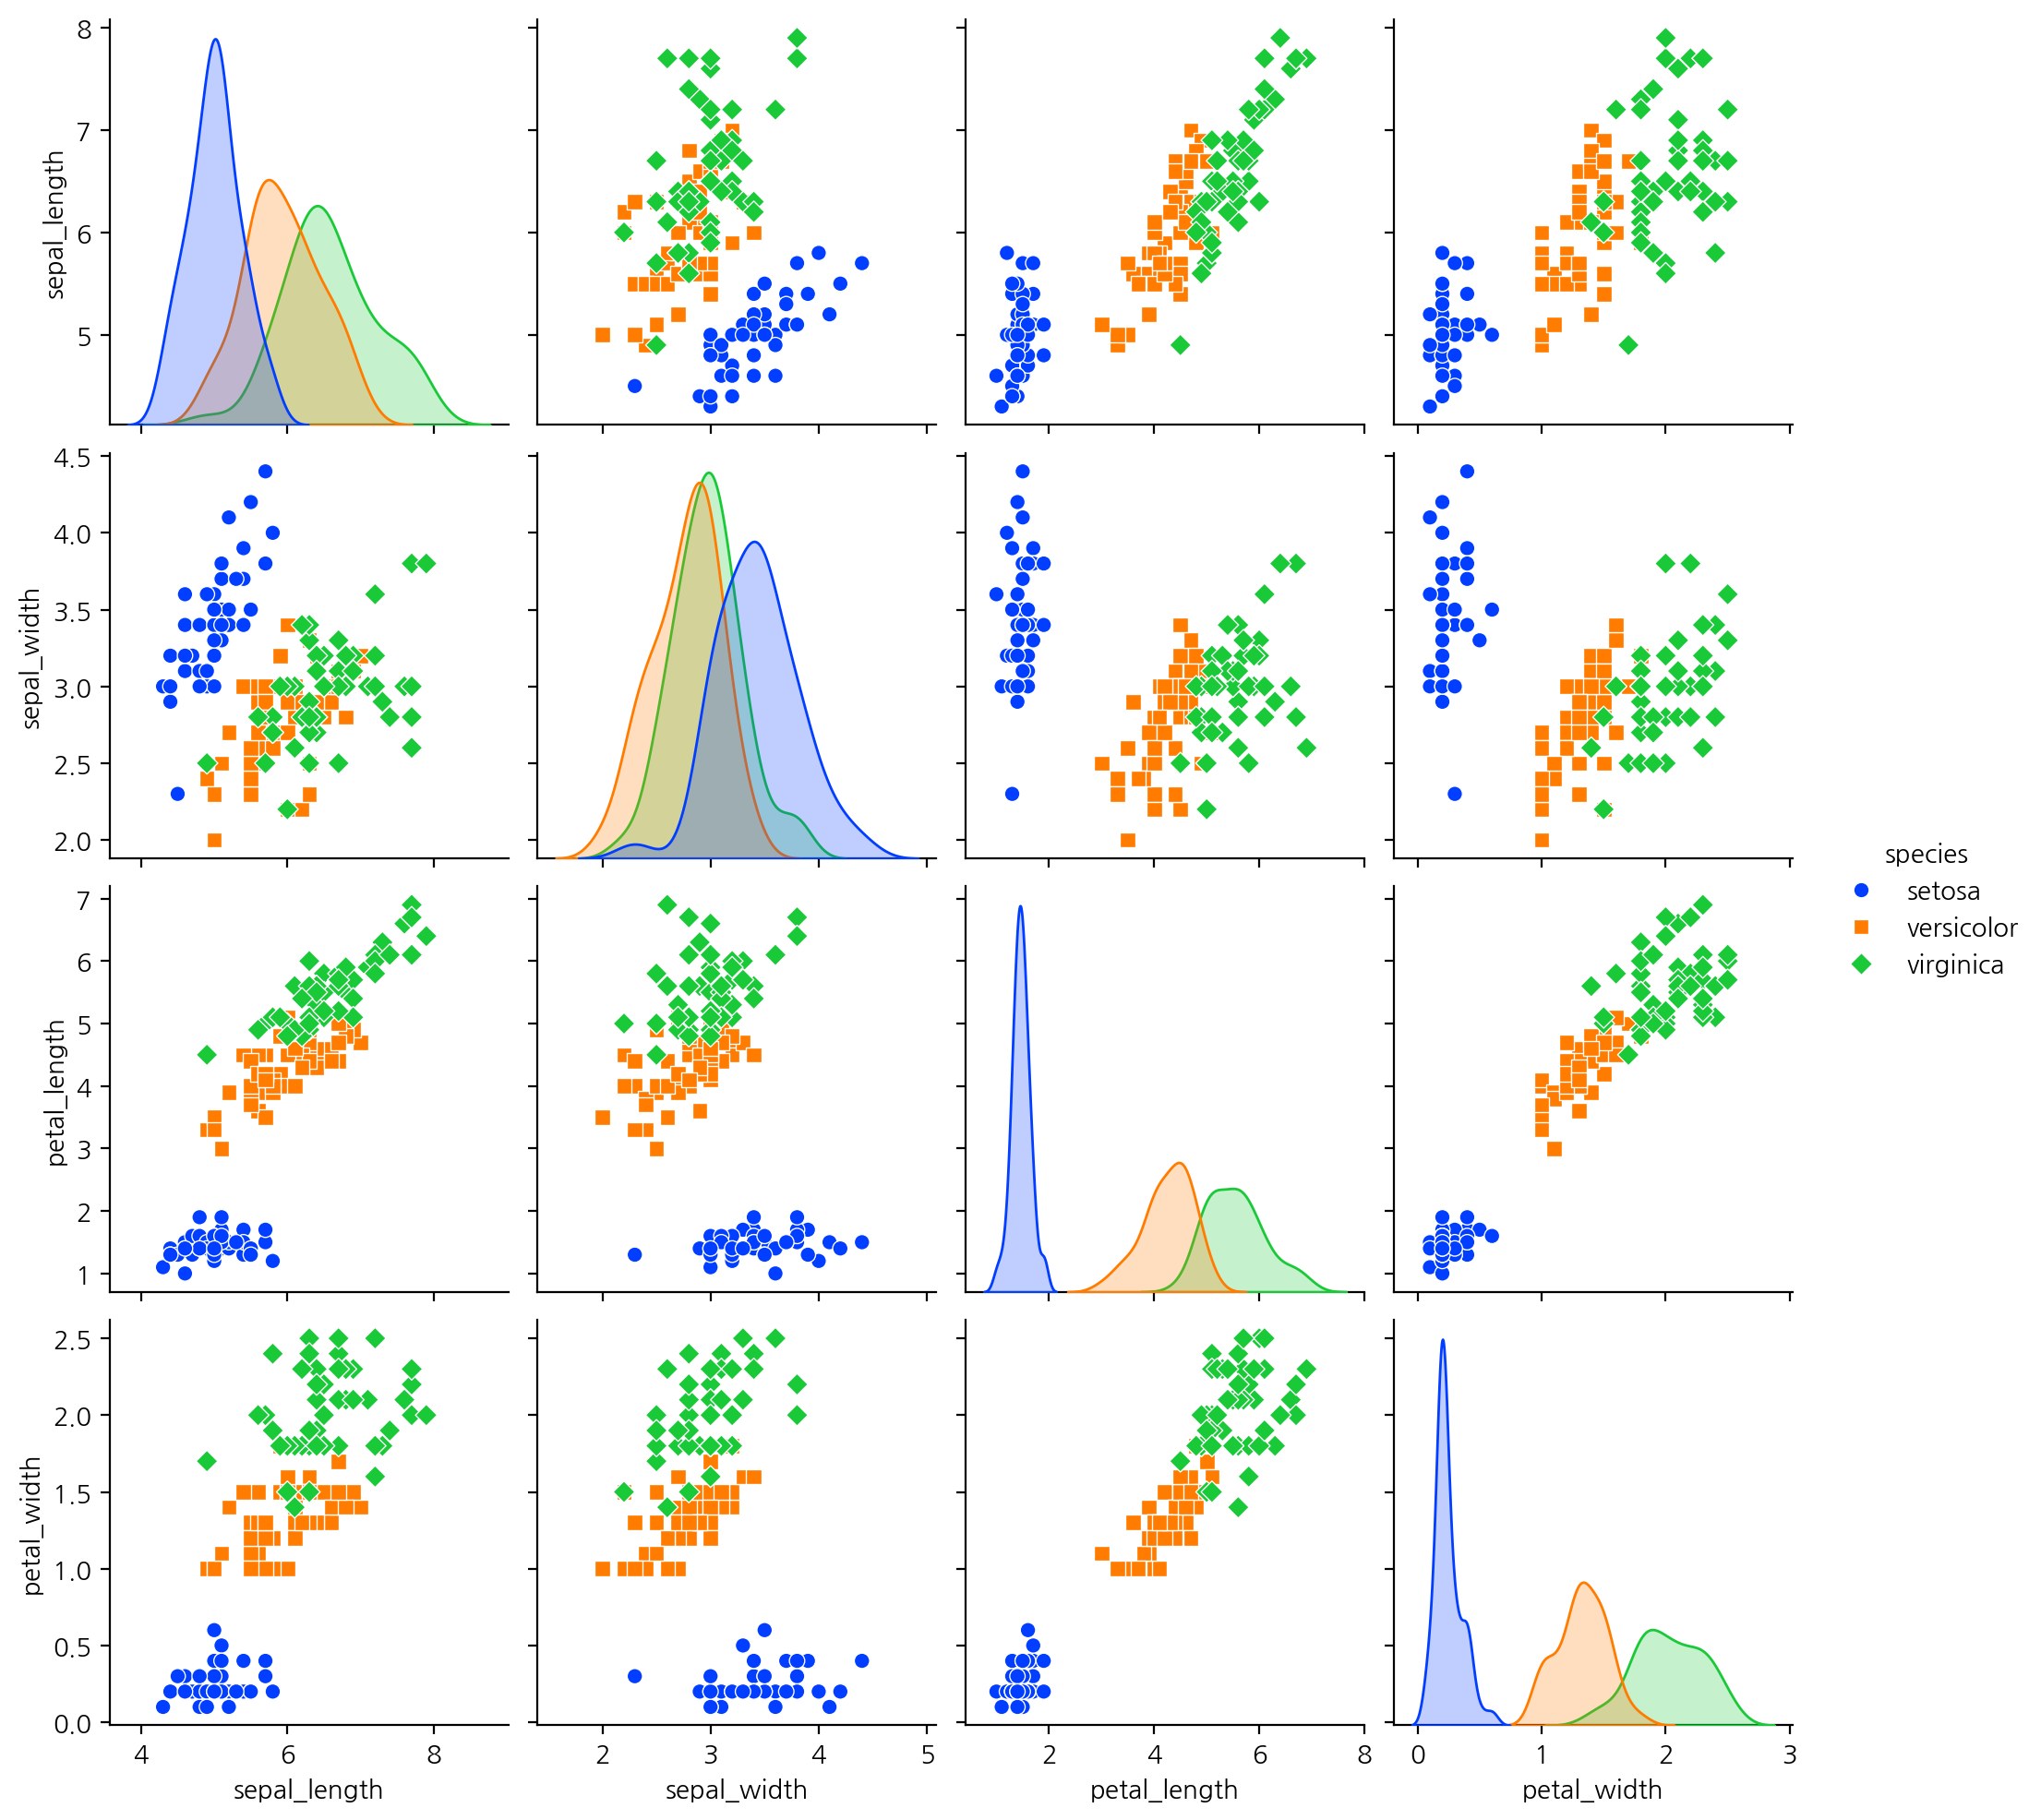

In [74]:
sns.pairplot(iris, hue="species", palette="bright", markers=["o", "s", "D"]);

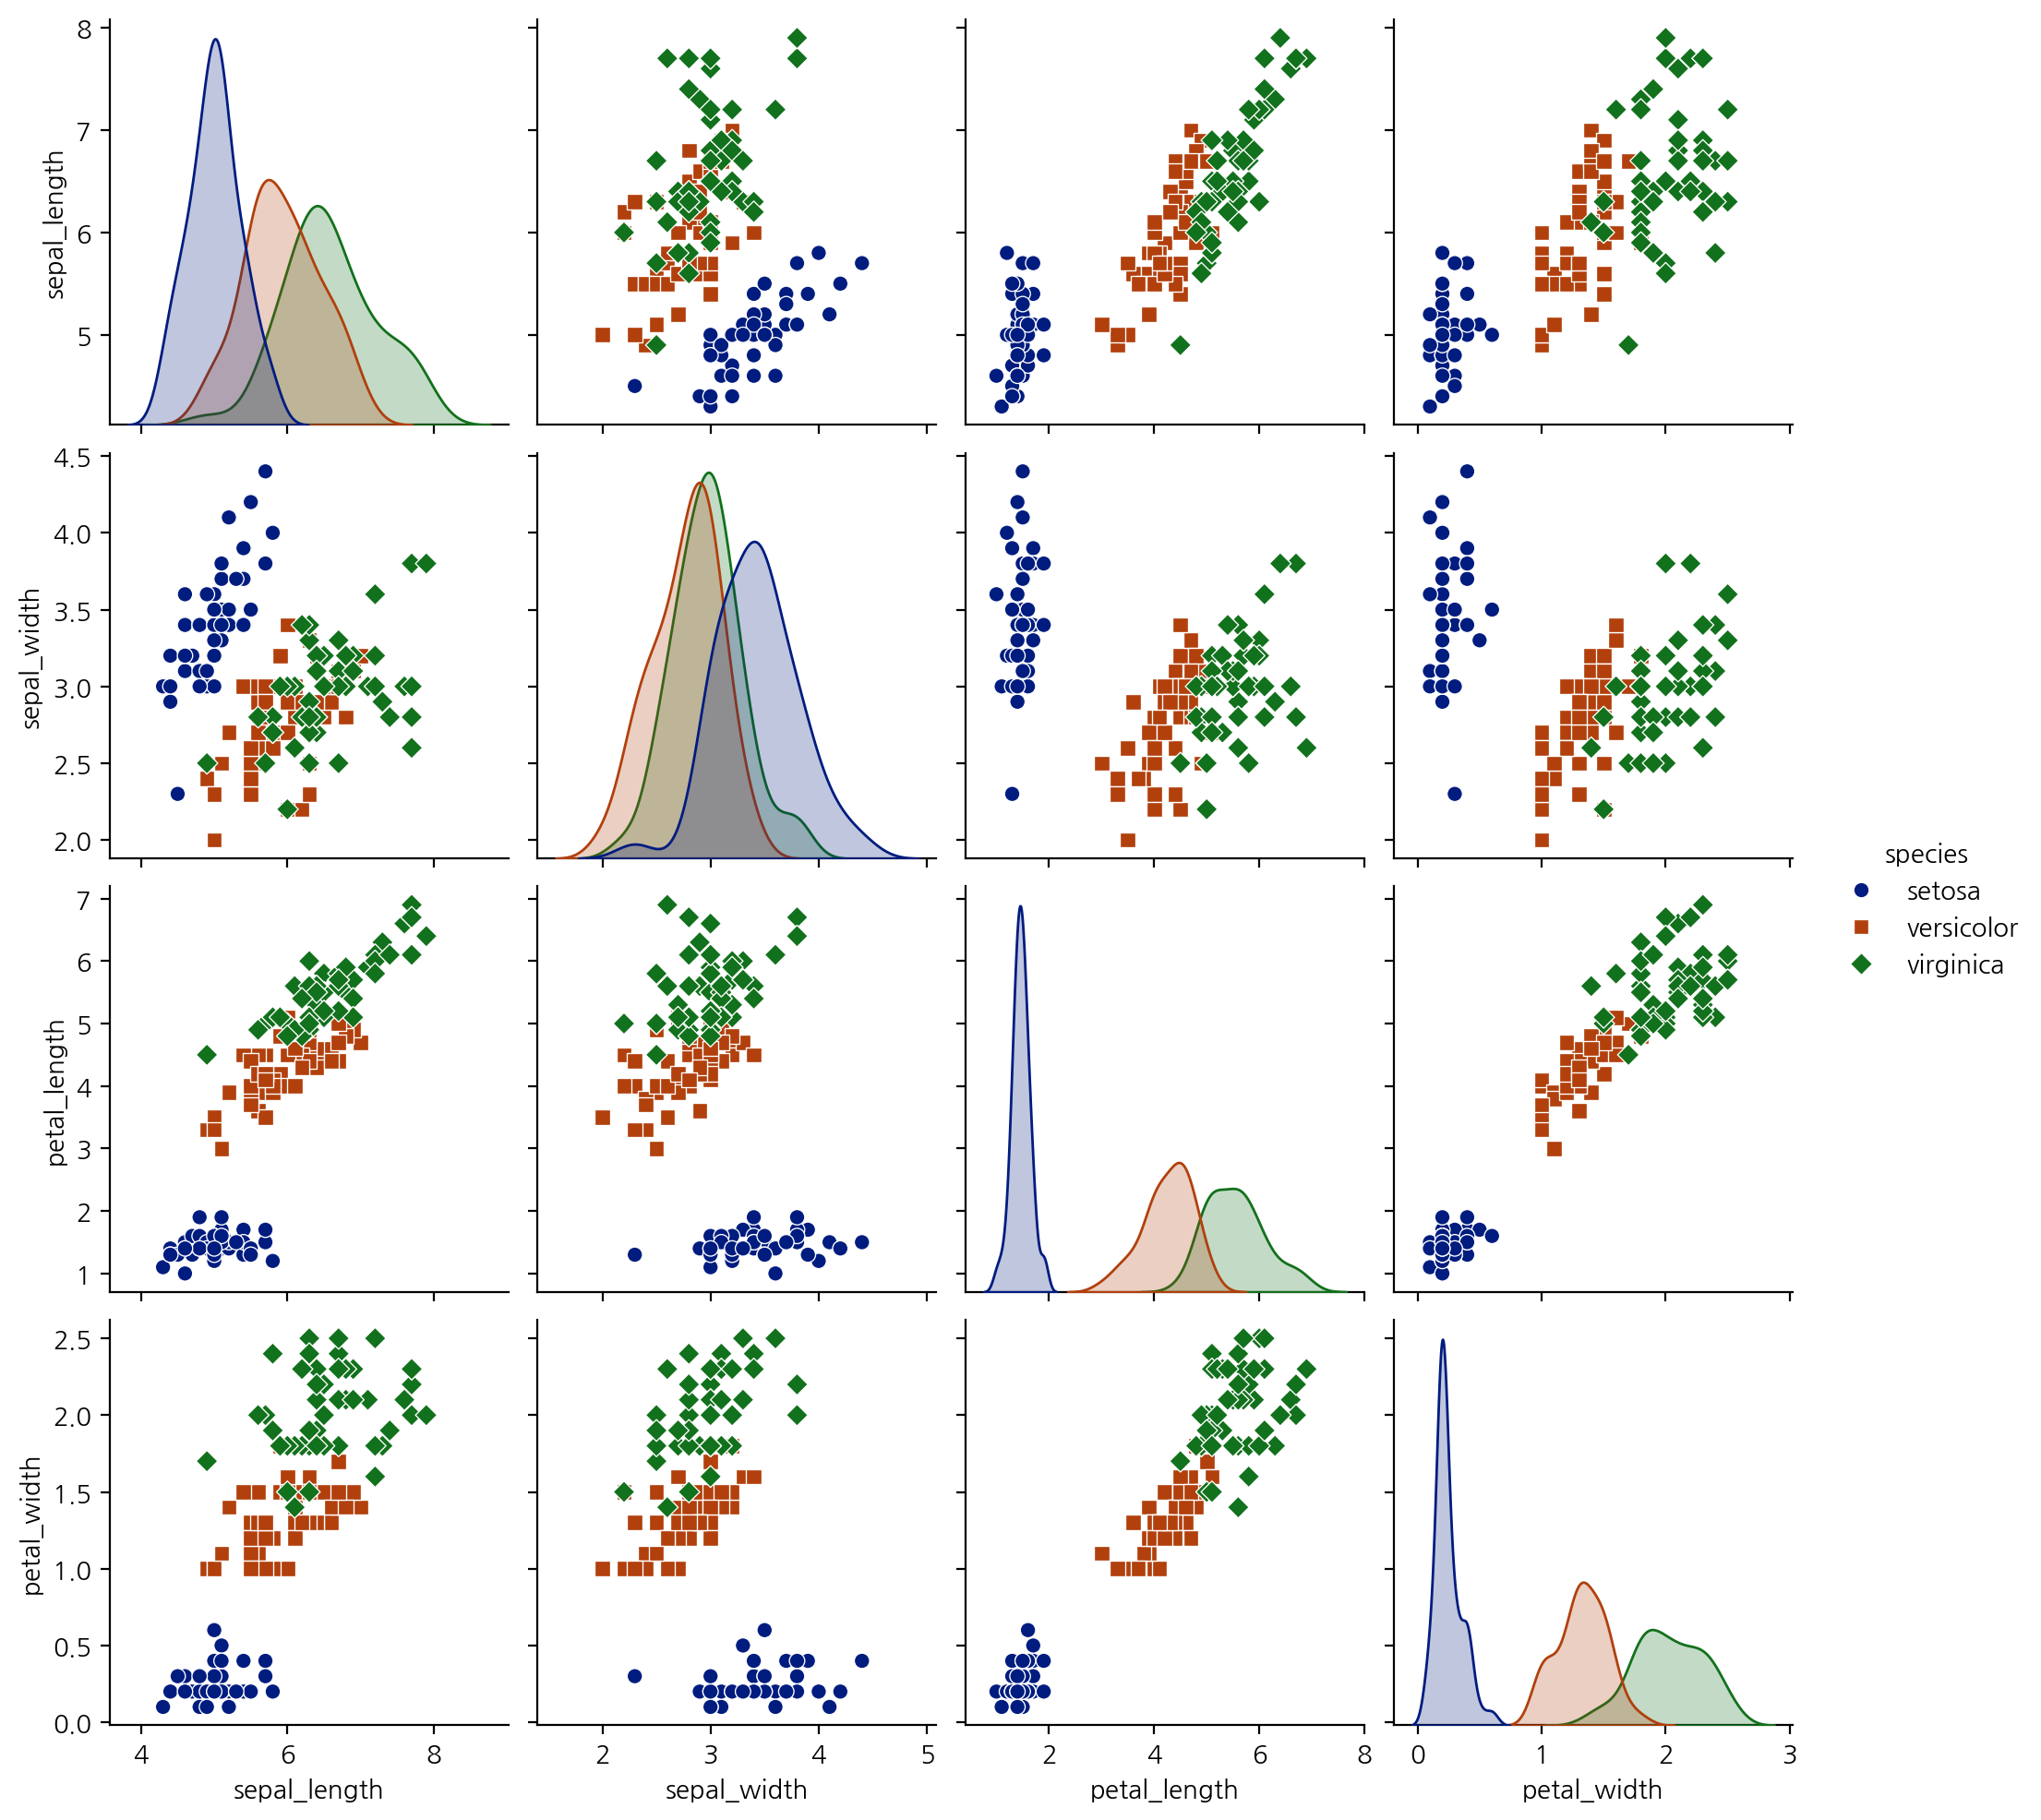

In [75]:
sns.pairplot(iris, hue="species", palette="dark", markers=["o", "s", "D"]);

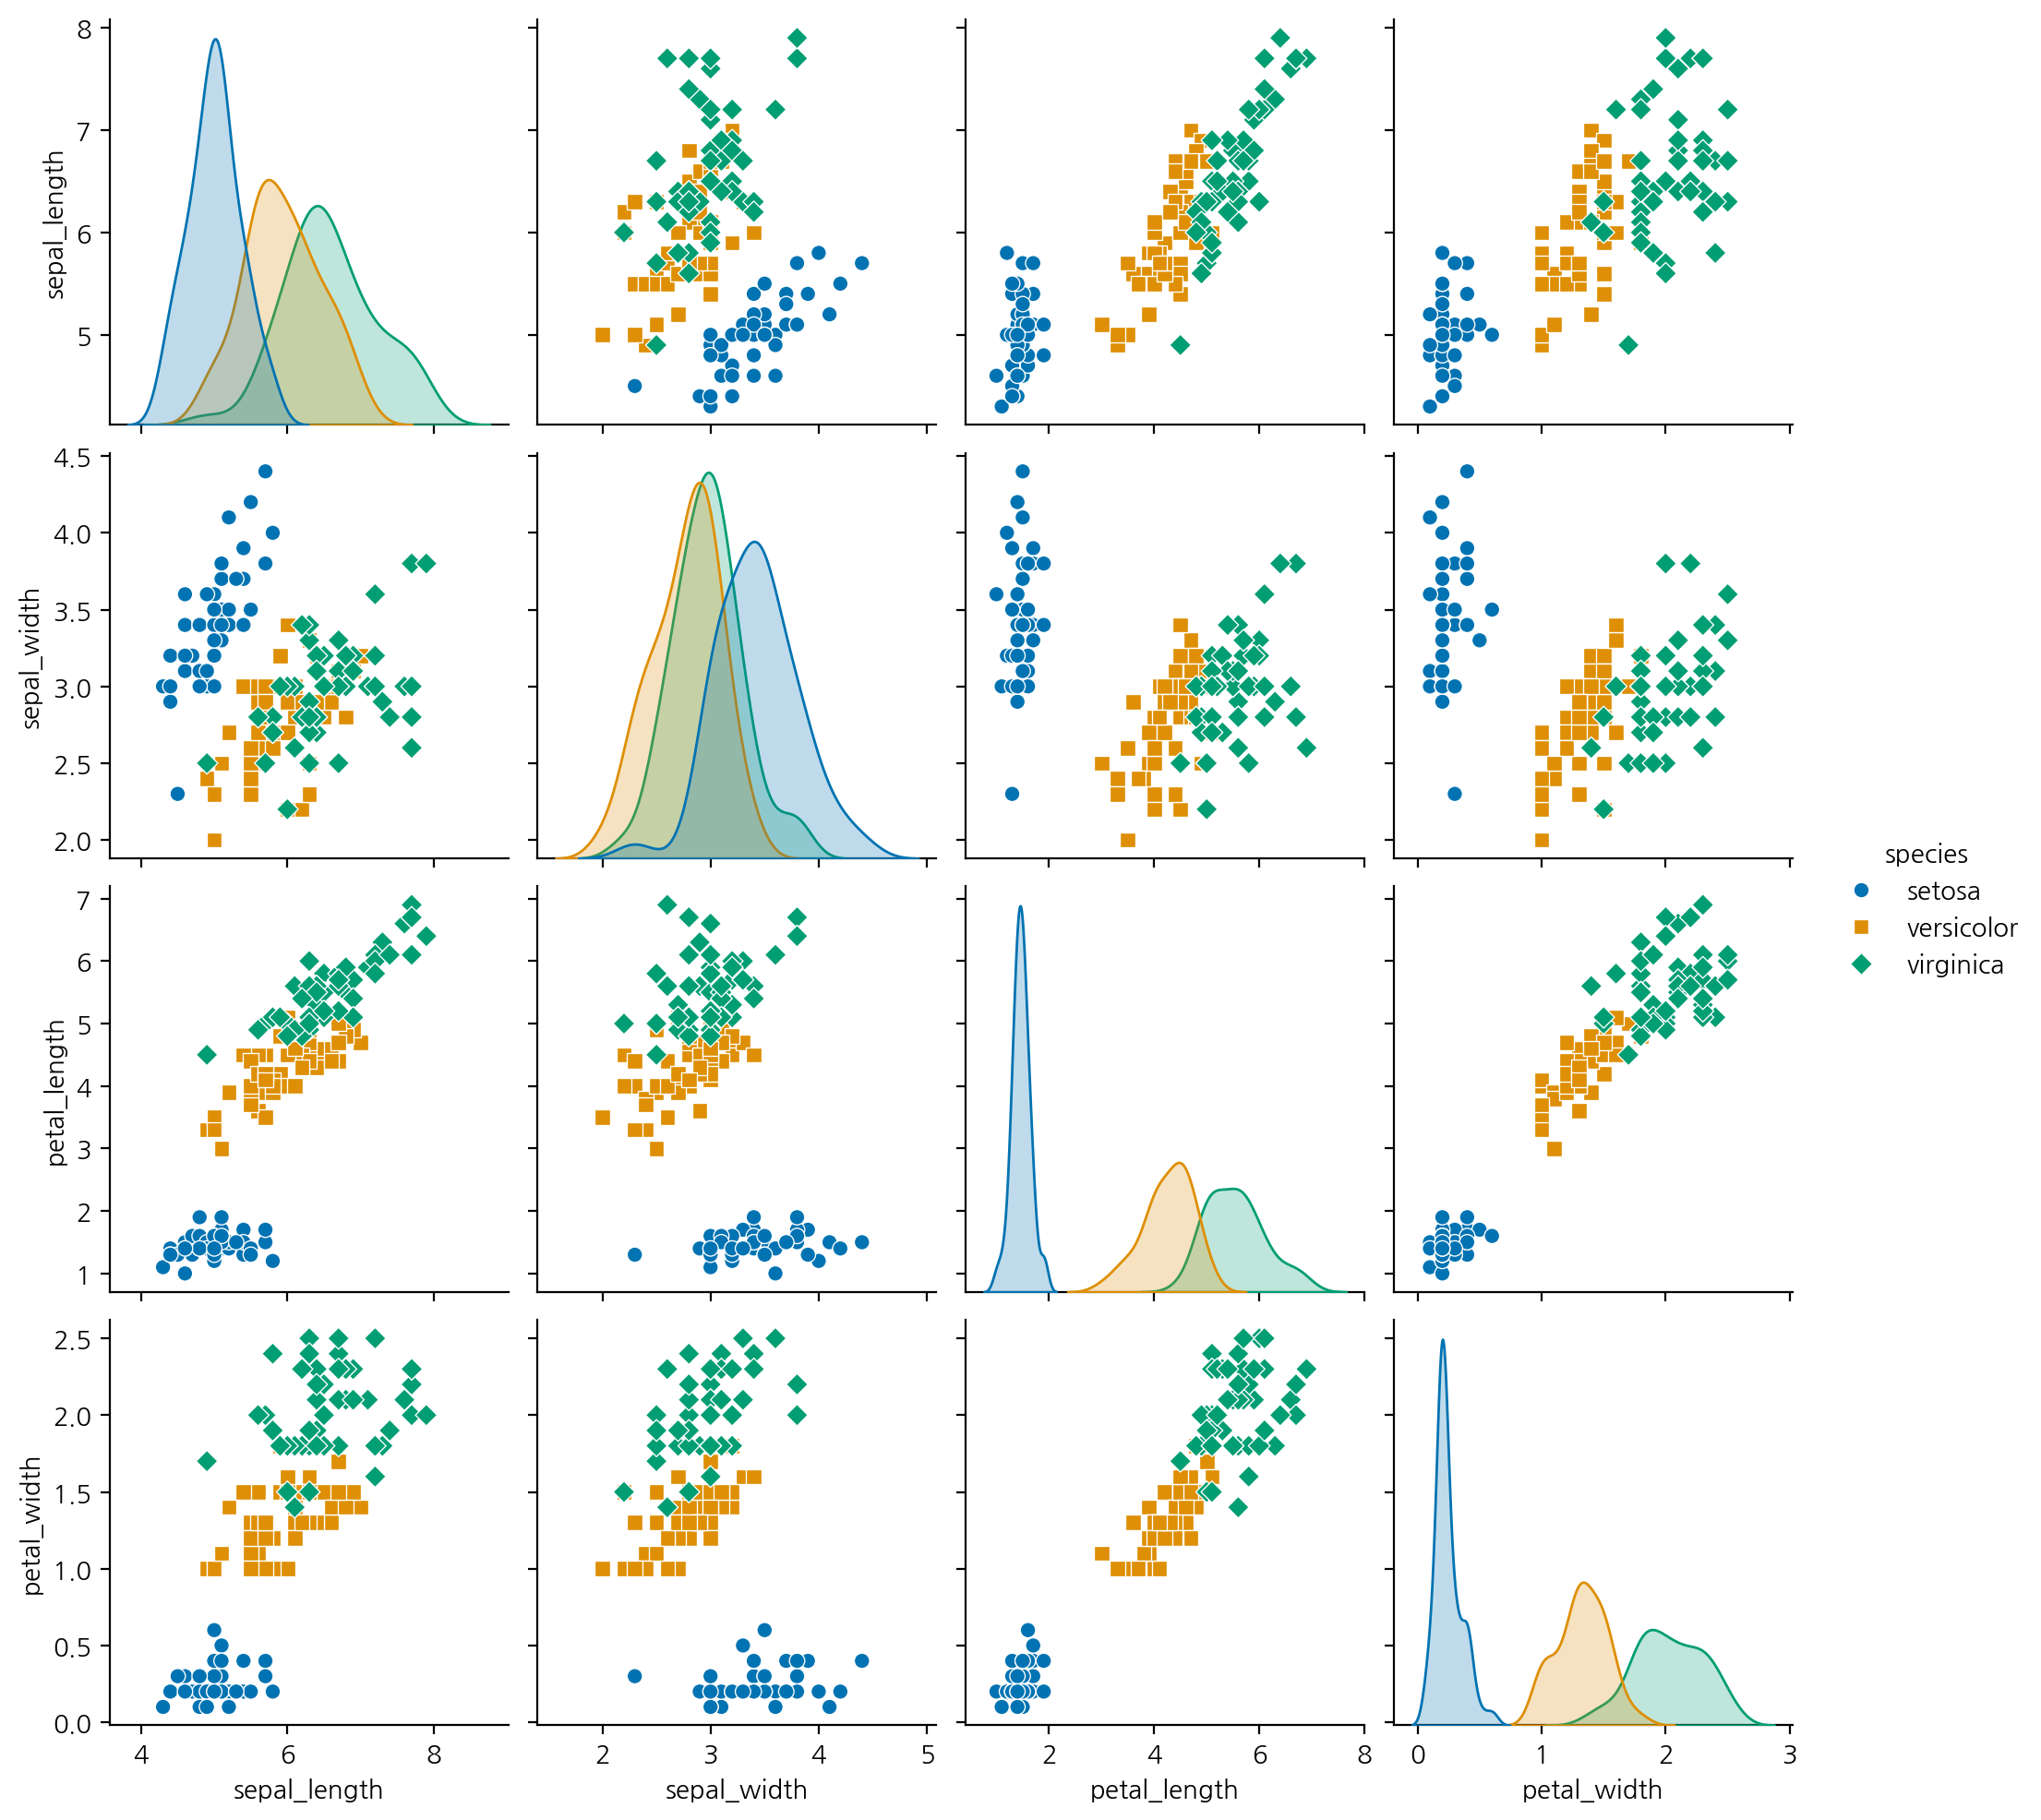

In [76]:
sns.pairplot(iris, hue="species", palette="colorblind", markers=["o", "s", "D"]);

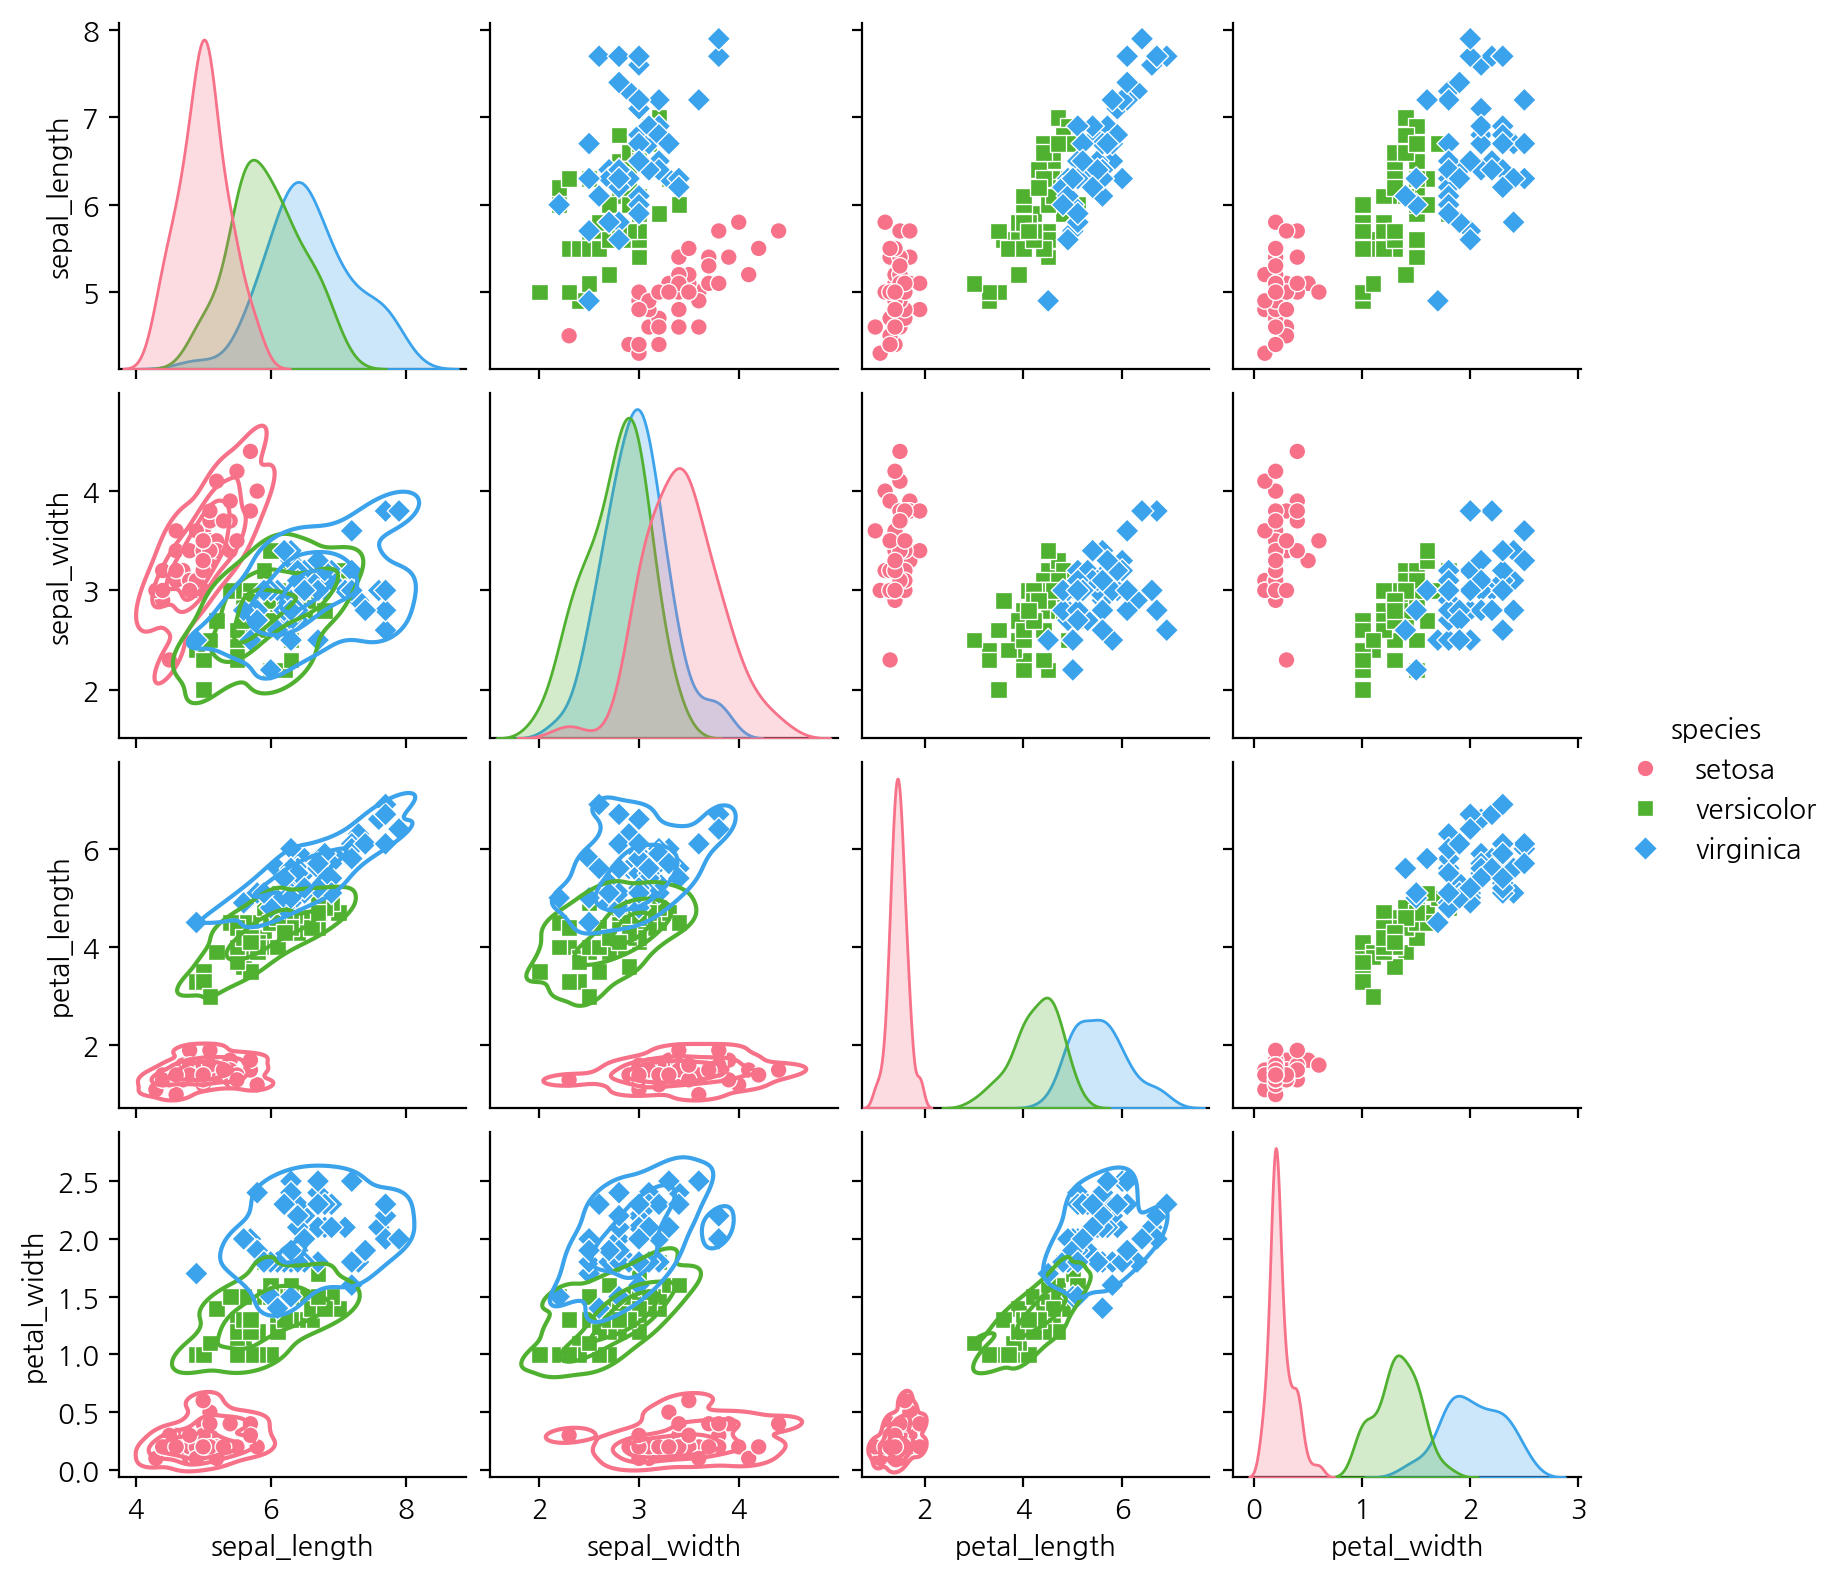

In [77]:
g = sns.pairplot(iris, hue="species",
palette="husl", height=2.0,
markers=["o", "s", "D"]);
g.map_lower(sns.kdeplot, levels=4,
color=".2");